In [1]:
print("Tokenizer 🚀")

Tokenizer 🚀


In [2]:
from transformers import AutoTokenizer

In [3]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")   # encoder-only

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [4]:
from transformers import AutoTokenizer

# ── 1. BERT (bert-base-uncased) ───────────────────────────────────────────────
# WordPiece tokenizer | lowercase | 30,522 vocab | adds [CLS] and [SEP] tokens
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

text = "Hello, I am learning Transformers!"

tokens     = tokenizer.tokenize(text)
encoded    = tokenizer(text, return_tensors="pt")
decoded    = tokenizer.decode(encoded["input_ids"][0])

print("Tokens  :", tokens)
# ['hello', ',', 'i', 'am', 'learning', 'transform', '##ers', '!']

print("input_ids :", encoded["input_ids"])
# tensor([[  101,  7592,  1010,  1045,  2572,  4083, 19081,  2015,   999,   102]])

print("Decoded :", decoded)
# [CLS] hello, i am learning transformers! [SEP]

Tokens  : ['hello', ',', 'i', 'am', 'learning', 'transformers', '!']
input_ids : tensor([[  101,  7592,  1010,  1045,  2572,  4083, 19081,   999,   102]])
Decoded : [CLS] hello, i am learning transformers! [SEP]


In [5]:
from transformers import AutoTokenizer

# ── BERT TOKENIZER (bert-base-uncased) ───────────────────────────────────────
# Algorithm    : WordPiece — greedy longest-match subword splitting
# Vocab size   : 30,522 tokens (words + subwords + special tokens)
# Case         : uncased — all input lowercased before any processing
# Special tokens added by __call__():
#   [CLS] = 101  → prepended  — sentence-level representation for classification
#   [SEP] = 102  → appended   — marks end of sequence / boundary between two sentences
# Subword marker : "##" prefix on continuation pieces
#   e.g. "transformers" → "transform" + "##ers"
#   "##" means "this piece is NOT a word start, it continues the previous piece"
# attention_mask : 1 for every real token, 0 for padding (padding absent here)
# ─────────────────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
text = "Hello, I am learning Transformers!"

# tokenize() → raw subword pieces only
# does NOT add [CLS]/[SEP], does NOT return IDs, does NOT return tensors
tokens = tokenizer.tokenize(text)

# __call__() → full pipeline in one shot:
#   lowercase → WordPiece split → prepend [CLS] → append [SEP] → convert to IDs → tensor
encoded = tokenizer(text, return_tensors="pt")

# decode() → ID list back to human-readable string
# by default keeps [CLS] and [SEP] visible
# pass skip_special_tokens=True to strip them
decoded = tokenizer.decode(encoded["input_ids"][0])


# ── WORDPIECE ALGORITHM (how splitting works internally) ─────────────────────
# 1. Lowercase the full string (uncased model only)
# 2. Split on whitespace and punctuation → raw words
# 3. For each word, greedily find the longest prefix that exists in vocab
#    - If the full word is in vocab → single token
#    - If not → take longest known prefix, mark the rest with "##", repeat
# 4. If no valid split found → replace with [UNK] token (id=100)
# Precondition : input must be a plain string (not pre-tokenized)
# Time  : O(n · L²) where n = words, L = max word length (greedy search per word)
# Space : O(V) where V = vocab size (30,522 entries loaded into memory)


# ── PIPELINE STAGES AND METHOD MAPPING ───────────────────────────────────────
# tokenizer.tokenize(text)        → Stage 1+2 only (lowercase + split), no IDs
# tokenizer(text)  / __call__()   → Full pipeline: Stage 1→2→3→4 + tensors
# tokenizer.encode(text)          → Same as __call__ but returns plain list of IDs
# tokenizer.decode(ids)           → Reverse: IDs → string, joins "##" pieces
# tokenizer.convert_tokens_to_ids → Stage 3 only (tokens → IDs, no specials added)


# ── DRY RUN : text = "Hello, I am learning Transformers!" ────────────────────

# Stage 1 — Lowercase (uncased model strips case before anything else)
# "Hello, I am learning Transformers!"
#  →  "hello, i am learning transformers!"

# Stage 2 — tokenizer.tokenize() : WordPiece split, no specials, no IDs
# word          pieces              reason
# hello      →  hello               whole word in vocab
# ,          →  ,                   punctuation split by BasicTokenizer
# i          →  i                   whole word in vocab
# am         →  am                  whole word in vocab
# learning   →  learning            whole word in vocab
# transformers→ transform + ##ers   "transformers" not in vocab
#                                   "transform" is longest known prefix
#                                   "ers" gets "##" marker → ##ers
# !          →  !                   punctuation split
#
# tokens = ['hello', ',', 'i', 'am', 'learning', 'transform', '##ers', '!']

# Stage 3 — tokenizer() : add specials + convert to IDs
# pos  token       id
#  0   [CLS]      101    ← always prepended
#  1   hello     7592
#  2   ,         1010
#  3   i         1045
#  4   am        2572
#  5   learning  4083
#  6   transform 19081
#  7   ##ers     2015
#  8   !          999
#  9   [SEP]      102    ← always appended
#
# encoded["input_ids"]      = tensor([[101, 7592, 1010, 1045, 2572, 4083, 19081, 2015, 999, 102]])
# encoded["attention_mask"] = tensor([[  1,    1,    1,    1,    1,    1,     1,    1,   1,   1]])
# encoded["token_type_ids"] = tensor([[  0,    0,    0,    0,    0,    0,     0,    0,   0,   0]])
# all zeros → single sentence (segment A); segment B would be all 1s

# Stage 4 — tokenizer.decode() : IDs → string, "##" pieces joined, specials visible
# 101   → [CLS]       (kept by default, pass skip_special_tokens=True to strip)
# 7592  → hello
# 1010  → ,
# 1045  → i
# 2572  → am
# 4083  → learning
# 19081 → transform ─┐
# 2015  → ##ers     ─┘  joined → "transformers"  (## stripped, no space inserted)
# 999   → !
# 102   → [SEP]       (kept by default)
#
# decoded = "[CLS] hello, i am learning transformers! [SEP]"

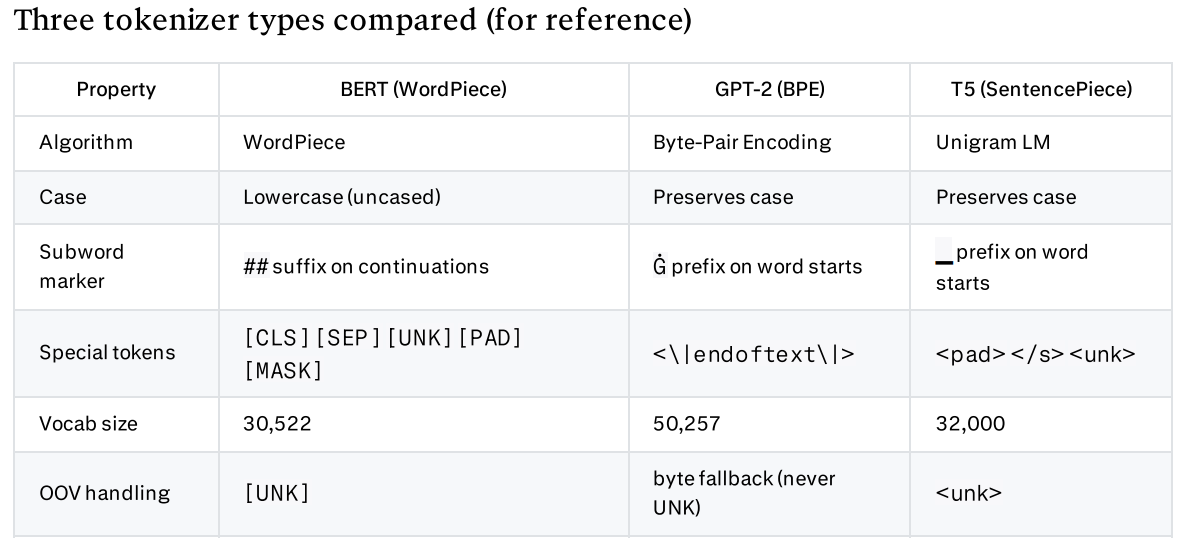

In [6]:

# ── 2. RoBERTa (roberta-base) ─────────────────────────────────────────────────
# BPE tokenizer | case-sensitive | 50,265 vocab | uses Ġ for space prefix
# Key diff from BERT: NO [CLS]/[SEP] — uses <s> and </s> instead
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

text = "Hello, I am learning Transformers!"

tokens  = tokenizer.tokenize(text)
encoded = tokenizer(text, return_tensors="pt")
decoded = tokenizer.decode(encoded["input_ids"][0])

print("Tokens  :", tokens)
# ['Hello', ',', 'ĠI', 'Ġam', 'Ġlearning', 'ĠTransformers', '!']

print("input_ids :", encoded["input_ids"])
# tensor([[    0, 31414,     6,    38,   524,  2239, 44091,   328,     2]])

print("Decoded :", decoded)
# <s>Hello, I am learning Transformers!</s>

# NOTE: Ġ = space before a word (BPE space prefix convention)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokens  : ['Hello', ',', 'ĠI', 'Ġam', 'Ġlearning', 'ĠTransformers', '!']
input_ids : tensor([[    0, 31414,     6,    38,   524,  2239, 34379,   328,     2]])
Decoded : <s>Hello, I am learning Transformers!</s>


In [7]:
from transformers import AutoTokenizer

# ── ROBERTA TOKENIZER (roberta-base) ─────────────────────────────────────────
# Algorithm    : Byte-Pair Encoding (BPE) — merges frequent character pairs
# Vocab size   : 50,265 tokens (larger than BERT)
# Case         : case-sensitive — preserves original casing ("Hello" ≠ "hello")
# Special tokens added by __call__():
#   <s>  = 0  → prepended  — start of sequence (similar to [CLS])
#   </s> = 2  → appended   — end of sequence (similar to [SEP])
# Subword marker : "Ġ" (U+0120) prefix indicates a space before the word
#   e.g. "Hello world" → "Hello", "Ġworld"
#   "Ġ" means "this token starts after a space"
# attention_mask : 1 for real tokens, 0 for padding (no padding here)
# token_type_ids : NOT used in RoBERTa (always omitted or None)
# ─────────────────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained("roberta-base")
text = "Hello, I am learning Transformers!"

# tokenize() → BPE subword pieces only
# does NOT add <s>/</s>, does NOT return IDs, does NOT return tensors
tokens = tokenizer.tokenize(text)

# __call__() → full pipeline:
#   byte-level split → BPE merge → add <s>, </s> → convert to IDs → tensor
encoded = tokenizer(text, return_tensors="pt")

# decode() → ID list back to string
# keeps <s>, </s> by default (use skip_special_tokens=True to remove)
decoded = tokenizer.decode(encoded["input_ids"][0])


# ── BPE ALGORITHM (how splitting works internally) ───────────────────────────
# 1. Input is converted to byte-level representation (handles any Unicode)
# 2. Frequent character pairs are merged iteratively (learned merges)
# 3. Space is encoded explicitly using "Ġ" prefix
#    - "word"  → no space before
#    - "Ġword" → space before word
# 4. Unknown words are NOT replaced with [UNK] easily (byte-level fallback exists)
# Precondition : raw string input (no manual token splitting required)
# Time  : O(n · merges)  (depends on merge rules)
# Space : O(V) where V = 50,265 vocab


# ── PIPELINE STAGES AND METHOD MAPPING ───────────────────────────────────────
# tokenizer.tokenize(text)        → BPE split only (no specials, no IDs)
# tokenizer(text) / __call__()    → Full pipeline: BPE → specials → IDs → tensors
# tokenizer.encode(text)          → Same as __call__ but returns list of IDs
# tokenizer.decode(ids)           → IDs → string, removes "Ġ" by adding spaces
# tokenizer.convert_tokens_to_ids → tokens → IDs only


# ── DRY RUN : text = "Hello, I am learning Transformers!" ────────────────────

# Stage 1 — No lowercasing (case preserved)
# "Hello, I am learning Transformers!"

# Stage 2 — tokenizer.tokenize() : BPE split
# token              meaning
# Hello           →  "Hello"           (start of sentence, no space prefix)
# ,               →  ","               (punctuation)
# ĠI              →  " I"              (space + I)
# Ġam             →  " am"
# Ġlearning       →  " learning"
# ĠTransformers  →  " Transformers"   (full word exists in vocab → no split)
# !               →  "!"
#
# tokens = ['Hello', ',', 'ĠI', 'Ġam', 'Ġlearning', 'ĠTransformers', '!']


# Stage 3 — tokenizer() : add specials + convert to IDs
# pos  token           id
#  0   <s>              0
#  1   Hello        31414
#  2   ,                6
#  3   ĠI              38
#  4   Ġam            524
#  5   Ġlearning     2239
#  6   ĠTransformers 44091
#  7   !              328
#  8   </s>             2
#
# encoded["input_ids"] =
# tensor([[    0, 31414,     6,    38,   524,  2239, 44091,   328,     2]])
#
# encoded["attention_mask"] =
# tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])
#
# encoded["token_type_ids"] = None  (RoBERTa does not use segment IDs)


# Stage 4 — tokenizer.decode() : IDs → string
# 0      → <s>
# 31414  → Hello
# 6      → ,
# 38     → ĠI          → " I"
# 524    → Ġam         → " am"
# 2239   → Ġlearning   → " learning"
# 44091  → ĠTransformers → " Transformers"
# 328    → !
# 2      → </s>
#
# decoded = "<s>Hello, I am learning Transformers!</s>"

In [8]:
from transformers import AutoTokenizer

# ── GPT-2 TOKENIZER (gpt2) ───────────────────────────────────────────────────
# Algorithm    : Byte-Pair Encoding (BPE) — byte-level merges (same family as RoBERTa)
# Vocab size   : 50,257 tokens
# Case         : case-sensitive — preserves original casing
# Special tokens:
#   GPT-2 does NOT automatically add start/end tokens during encoding
#   eos_token = 50256  → used as end-of-sequence (optional, not auto-added)
#   pad_token = None   → must be manually set for batching
# Subword marker : "Ġ" prefix indicates a space before the word (like RoBERTa)
#   e.g. "Hello world" → "Hello", "Ġworld"
# attention_mask : 1 for real tokens, 0 for padding (padding absent here)
# token_type_ids : NOT used (decoder-only architecture)
# ─────────────────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained("gpt2")

# GPT-2 has NO pad token → must assign manually for batching
tokenizer.pad_token = tokenizer.eos_token

text = "Hello, I am learning Transformers!"

# tokenize() → BPE pieces only (no specials, no IDs)
tokens = tokenizer.tokenize(text)

# __call__() → full pipeline:
#   byte-level BPE → convert to IDs → tensor
#   (NO <s>, </s>, [CLS], [SEP] added)
encoded = tokenizer(text, return_tensors="pt")

# decode() → IDs → string (restores spaces from "Ġ")
decoded = tokenizer.decode(encoded["input_ids"][0])


# ── BPE ALGORITHM (byte-level, GPT-2 style) ──────────────────────────────────
# 1. Convert text into byte-level representation (covers all Unicode)
# 2. Apply learned merge rules to combine frequent byte pairs
# 3. Space handled explicitly using "Ġ"
# 4. No [UNK] — every input can be represented via bytes
# Precondition : raw string input
# Time  : O(n · merges)
# Space : O(V) where V = 50,257


# ── PIPELINE STAGES AND METHOD MAPPING ───────────────────────────────────────
# tokenizer.tokenize(text)        → BPE split only (no IDs)
# tokenizer(text) / __call__()    → BPE → IDs → tensors (no special tokens)
# tokenizer.encode(text)          → same but returns list of IDs
# tokenizer.decode(ids)           → IDs → string, reconstructs spaces
# tokenizer.convert_tokens_to_ids → tokens → IDs only


# ── DRY RUN : text = "Hello, I am learning Transformers!" ────────────────────

# Stage 1 — No lowercasing (case preserved)
# "Hello, I am learning Transformers!"

# Stage 2 — tokenizer.tokenize() : BPE split
# token              meaning
# Hello           →  "Hello"
# ,               →  ","
# ĠI              →  " I"
# Ġam             →  " am"
# Ġlearning       →  " learning"
# ĠTransform      →  " Transform"
# ers             →  continuation (no Ġ → no leading space)
# !               →  "!"
#
# tokens = ['Hello', ',', 'ĠI', 'Ġam', 'Ġlearning', 'ĠTransform', 'ers', '!']


# Stage 3 — tokenizer() : convert to IDs (NO special tokens added)
# pos  token           id
#  0   Hello        15496
#  1   ,               11
#  2   ĠI             314
#  3   Ġam            716
#  4   Ġlearning     4673
#  5   ĠTransform   48108
#  6   ers             68
#  7   !                0
#
# encoded["input_ids"] =
# tensor([[15496,    11,   314,   716,  4673, 48108,    68,     0]])
#
# encoded["attention_mask"] =
# tensor([[1, 1, 1, 1, 1, 1, 1, 1]])
#
# encoded["token_type_ids"] = None  (not used)


# Stage 4 — tokenizer.decode() : IDs → string
# 15496 → Hello
# 11    → ,
# 314   → ĠI         → " I"
# 716   → Ġam        → " am"
# 4673  → Ġlearning  → " learning"
# 48108 → ĠTransform → " Transform"
# 68    → ers        → joins → "Transformers"
# 0     → !
#
# decoded = "Hello, I am learning Transformers!"


# ── IMPORTANT NOTES (GPT-2 SPECIFIC) ─────────────────────────────────────────
# • No automatic special tokens → model is purely causal (left-to-right)
# • eos_token (50256) must be added manually if needed:
#     tokenizer(text, add_special_tokens=True)  # still may not add like BERT
# • Padding must be explicitly handled:
#     tokenizer(texts, padding=True, return_tensors="pt")
# • Same tokenizer family as RoBERTa, but behavior differs in:
#     - No <s>, </s>
#     - No classification token
#     - Designed for generation, not classification

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
# T5 TOKENIZER

In [10]:
from transformers import AutoTokenizer

# ── T5 TOKENIZER (t5-base) ────────────────────────────────────────────────────
# Algorithm    : SentencePiece — Unigram Language Model
# Vocab size   : 32,100 tokens (32,000 + extra_ids sentinel tokens)
# Case         : case-sensitive — preserves original casing
# Special tokens:
#   pad_token  = "<pad>"  (id=0)  → default padding token
#   eos_token  = "</s>"   (id=1)  → added automatically at end of input
#   unk_token  = "<unk>"  (id=2)
#   extra_ids  = <extra_id_0> … <extra_id_99> → sentinel tokens for span masking
# Subword marker : "▁" (U+2581) prefix indicates space/word boundary
#   e.g. "Hello world" → "▁Hello", "▁world"
# attention_mask : 1 for real tokens, 0 for padding
# token_type_ids : NOT used (encoder-decoder architecture)
# Key behavior   : </s> is appended automatically on __call__()
#                  Encoder-decoder → tokenizer handles src; decoder uses
#                  decoder_start_token_id (usually pad_token_id=0)
# ─────────────────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained("t5-base")

text = "Hello, I am learning Transformers!"

# tokenize() → SentencePiece Unigram pieces (no IDs, no </s>)
tokens = tokenizer.tokenize(text)

# __call__() → full pipeline:
#   SentencePiece Unigram → IDs → tensor
#   </s> (id=1) is appended automatically
encoded = tokenizer(text, return_tensors="pt")

# decode() → IDs → string (strips ▁, reconstructs spaces, strips </s> by default)
decoded = tokenizer.decode(encoded["input_ids"][0], skip_special_tokens=True)


# ── UNIGRAM ALGORITHM (SentencePiece) ────────────────────────────────────────
# 1. Normalize text (NFC Unicode normalization, no lowercasing for T5)
# 2. SentencePiece treats the text as a raw byte stream — no pre-tokenization
# 3. Prefix "▁" encodes a space (word boundary) — first word also gets ▁
# 4. Unigram LM picks the tokenization that maximizes sequence probability
#    (trained on a unigram language model over subword candidates)
# 5. Falls back to <unk> for truly unknown sequences (rare with SP)
# Precondition : raw string input
# Time  : O(n²) Viterbi decoding
# Space : O(V) where V = 32,100


# ── PIPELINE STAGES AND METHOD MAPPING ───────────────────────────────────────
# tokenizer.tokenize(text)        → SP pieces only (no IDs, no </s>)
# tokenizer(text) / __call__()    → SP → IDs → append </s> → tensors
# tokenizer.encode(text)          → same but returns list of IDs
# tokenizer.decode(ids)           → IDs → string, reconstructs spaces via ▁
# tokenizer.convert_tokens_to_ids → tokens → IDs only


# ── DRY RUN : text = "Hello, I am learning Transformers!" ────────────────────

# Stage 1 — No lowercasing (case preserved)
# "Hello, I am learning Transformers!"

# Stage 2 — tokenizer.tokenize() : SentencePiece Unigram split
# token              meaning
# ▁Hello          →  " Hello"   (▁ marks word start / leading space)
# ,               →  ","
# ▁I              →  " I"
# ▁am             →  " am"
# ▁learning       →  " learning"
# ▁Transform      →  " Transform"
# ers             →  continuation (no ▁ → no word boundary)
# !               →  "!"
#
# tokens = ['▁Hello', ',', '▁I', '▁am', '▁learning', '▁Transform', 'ers', '!']


# Stage 3 — tokenizer() : convert to IDs + append </s>
# pos  token           id      (approx — may vary by SP model version)
#  0   ▁Hello         8774
#  1   ,                 6
#  2   ▁I               27
#  3   ▁am             183
#  4   ▁learning       1036
#  5   ▁Transform      5765
#  6   ers              357
#  7   !                 55
#  8   </s>               1   ← auto-appended
#
# encoded["input_ids"] =
# tensor([[8774, 6, 27, 183, 1036, 5765, 357, 55, 1]])
#
# encoded["attention_mask"] =
# tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])
#
# encoded["token_type_ids"] = None  (not used)


# Stage 4 — tokenizer.decode() : IDs → string
# 8774 → ▁Hello      → "Hello"
# 6    → ,           → ","
# 27   → ▁I          → " I"
# 183  → ▁am         → " am"
# 1036 → ▁learning   → " learning"
# 5765 → ▁Transform  → " Transform"
# 357  → ers         → joins → "Transformers"
# 55   → !           → "!"
# 1    → </s>        → stripped (skip_special_tokens=True)
#
# decoded = "Hello, I am learning Transformers!"


# ── IMPORTANT NOTES (T5 SPECIFIC) ─────────────────────────────────────────────
# • </s> always appended → always strip it in decode() via skip_special_tokens
# • For seq2seq tasks, use as_target_tokenizer() for label encoding:
#     with tokenizer.as_target_tokenizer():
#         labels = tokenizer(target_text, return_tensors="pt")
# • Sentinel tokens (<extra_id_0> …) used for span-corruption pre-training:
#     tokenizer.additional_special_tokens → lists all sentinel IDs
# • Padding is left by default: tokenizer(texts, padding="longest")
# • decoder_start_token_id = 0 (<pad>) — T5 decoder primed with <pad>
# • For generation: model.generate() handles decoder start automatically

config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [13]:
import os
from huggingface_hub import login
from dotenv import load_dotenv
load_dotenv()

os.environ["HF_TOKEN"] = os.getenv("HF_READ_TOKEN", "")
login(token=os.environ["HF_TOKEN"])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [14]:
from transformers import AutoTokenizer

# ── LLAMA-2 TOKENIZER (meta-llama/Llama-2-7b-hf) ─────────────────────────────
# Algorithm    : SentencePiece — Byte-Pair Encoding (BPE)
#                (SP-BPE differs from GPT-2 BPE: uses ▁ not Ġ, trained with SP)
# Vocab size   : 32,000 tokens
# Case         : case-sensitive — preserves original casing
# Special tokens:
#   bos_token  = "<s>"   (id=1)  → added automatically at start (add_bos=True)
#   eos_token  = "</s>"  (id=2)  → NOT added automatically (must be manual)
#   unk_token  = "<unk>" (id=0)
#   pad_token  = None            → not defined; must be set manually for batching
# Subword marker : "▁" (U+2581) prefix — same as T5/SentencePiece convention
#   e.g. "Hello world" → "▁Hello", "▁world"
# attention_mask : 1 for real tokens, 0 for padding
# token_type_ids : NOT used (decoder-only architecture)
# Key behavior   : <s> (BOS) prepended automatically by default
#                  </s> (EOS) must be appended manually for generation stopping
# ─────────────────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-hf")

# Llama-2 has NO pad token → must assign for batching
tokenizer.pad_token = tokenizer.eos_token

text = "Hello, I am learning Transformers!"

# tokenize() → SP-BPE pieces only (no IDs, no <s>)
tokens = tokenizer.tokenize(text)

# __call__() → full pipeline:
#   SentencePiece BPE → IDs → tensor
#   <s> (id=1) prepended automatically (add_special_tokens=True by default)
encoded = tokenizer(text, return_tensors="pt")

# decode() → IDs → string (strips ▁, reconstructs spaces)
decoded = tokenizer.decode(encoded["input_ids"][0], skip_special_tokens=True)


# ── SP-BPE ALGORITHM (SentencePiece, Llama-2 style) ─────────────────────────
# 1. Normalize text (NFKC normalization, no lowercasing)
# 2. SentencePiece directly encodes raw text — no whitespace pre-split
# 3. Prefix "▁" marks a word boundary (space before word)
# 4. Apply learned BPE merge rules bottom-up (byte pairs → subwords)
# 5. Guarantees full coverage — no <unk> for standard text (byte fallback)
# Precondition : raw string input
# Time  : O(n · merges)
# Space : O(V) where V = 32,000


# ── PIPELINE STAGES AND METHOD MAPPING ───────────────────────────────────────
# tokenizer.tokenize(text)        → SP-BPE pieces (no IDs, no <s>)
# tokenizer(text) / __call__()    → SP-BPE → IDs → prepend <s> → tensors
# tokenizer.encode(text)          → same but returns list of IDs
# tokenizer.decode(ids)           → IDs → string, reconstructs spaces via ▁
# tokenizer.convert_tokens_to_ids → tokens → IDs only


# ── DRY RUN : text = "Hello, I am learning Transformers!" ────────────────────

# Stage 1 — No lowercasing (case preserved)
# "Hello, I am learning Transformers!"

# Stage 2 — tokenizer.tokenize() : SP-BPE split (no <s> here)
# token              meaning
# ▁Hello          →  " Hello"   (▁ marks word start)
# ,               →  ","
# ▁I              →  " I"
# ▁am             →  " am"
# ▁learning       →  " learning"
# ▁Transform      →  " Transform"
# ers             →  continuation (no ▁ → no word boundary)
# !               →  "!"
#
# tokens = ['▁Hello', ',', '▁I', '▁am', '▁learning', '▁Transform', 'ers', '!']


# Stage 3 — tokenizer() : prepend <s> + convert to IDs
# pos  token           id      (approx — may vary by HF model version)
#  0   <s>               1   ← auto-prepended (BOS)
#  1   ▁Hello        15043
#  2   ,             29892
#  3   ▁I              306
#  4   ▁am             626
#  5   ▁learning      6509
#  6   ▁Transform     4103
#  7   ers             414
#  8   !             29991
#
# encoded["input_ids"] =
# tensor([[1, 15043, 29892, 306, 626, 6509, 4103, 414, 29991]])
#
# encoded["attention_mask"] =
# tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])
#
# encoded["token_type_ids"] = None  (not used)


# Stage 4 — tokenizer.decode() : IDs → string
# 1     → <s>        → stripped (skip_special_tokens=True)
# 15043 → ▁Hello     → "Hello"
# 29892 → ,          → ","
# 306   → ▁I         → " I"
# 626   → ▁am        → " am"
# 6509  → ▁learning  → " learning"
# 4103  → ▁Transform → " Transform"
# 414   → ers        → joins → "Transformers"
# 29991 → !          → "!"
#
# decoded = "Hello, I am learning Transformers!"


# ── IMPORTANT NOTES (LLAMA-2 SPECIFIC) ───────────────────────────────────────
# • BOS <s> is always prepended → all sequences start with id=1
# • EOS </s> is NOT auto-added → must append manually for generation:
#     tokenizer(text + tokenizer.eos_token)
#     or use model.generate(eos_token_id=tokenizer.eos_token_id)
# • No pad token → set before batching to avoid errors:
#     tokenizer.pad_token = tokenizer.eos_token
#     (or add a new [PAD] token and resize embeddings)
# • For chat / instruction tuning, wrap with prompt template:
#     "[INST] {user_msg} [/INST]"  → Llama-2-Chat expected format
# • tokenizer.apply_chat_template() available in newer HF versions
# • Same SP-BPE family as Mistral, Falcon (SP) — but vocab/merges differ
# • GPT-2 vs Llama-2 BPE difference:
#     GPT-2 : byte-level BPE using "Ġ" (HuggingFace BPE)
#     Llama-2: SentencePiece BPE using "▁" (SP library)
#     Both handle all Unicode — different encoding paths

config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

In [16]:
# tokenize() → SP-BPE pieces only (no IDs, no <s>)
tokens = tokenizer.tokenize(text)

# __call__() → full pipeline:
#   SentencePiece BPE → IDs → tensor
#   <s> (id=1) prepended automatically (add_special_tokens=True by default)
encoded = tokenizer(text, return_tensors="pt")

# decode() → IDs → string (strips ▁, reconstructs spaces)
decoded = tokenizer.decode(encoded["input_ids"][0], skip_special_tokens=True)

In [20]:
print("Tokens  :", tokens)

print("input_ids :", encoded["input_ids"])

print("Decoded :", decoded)

Tokens  : ['▁Hello', ',', '▁I', '▁am', '▁learning', '▁Trans', 'form', 'ers', '!']
input_ids : tensor([[    1, 15043, 29892,   306,   626,  6509,  4103,   689,   414, 29991]])
Decoded : Hello, I am learning Transformers!


In [2]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

print(tokenizer.vocab_size)        # 30522 for bert-base-uncased
print(tokenizer.model_max_length)  # 512 — max tokens this model accepts
print(tokenizer.is_fast)           # True if Rust-based fast tokenizer

# special tokens
print(tokenizer.cls_token)         # [CLS] — start of sequence
print(tokenizer.sep_token)         # [SEP] — end of sequence / separator
print(tokenizer.pad_token)         # [PAD] — padding token
print(tokenizer.unk_token)         # [UNK] — unknown words
print(tokenizer.mask_token)        # [MASK] — masked token for MLM
print(tokenizer.bos_token)         # BOS — beginning of sequence (GPT-style)
print(tokenizer.eos_token)         # EOS — end of sequence (GPT-style)

# special token IDs
print(tokenizer.cls_token_id)      # 101
print(tokenizer.sep_token_id)      # 102
print(tokenizer.pad_token_id)      # 0
print(tokenizer.unk_token_id)      # 100

# full vocabulary
vocab = tokenizer.get_vocab()      # dict of token → id
print(len(vocab))                  # vocab size

30522
512
True
[CLS]
[SEP]
[PAD]
[UNK]
[MASK]
None
None
101
102
0
100
30522


In [3]:
from transformers import AutoTokenizer

# ── BERT TOKENIZER PROPERTIES & INSPECTION (bert-base-uncased) ─────────────────────
# These attributes give you direct access to the tokenizer's configuration
# without needing to encode any text. All values are loaded from:
#   • vocab.txt               (the actual vocabulary file)
#   • tokenizer_config.json   (special token mappings, model_max_length, etc.)
#   • tokenizer.json          (fast tokenizer metadata)
# ─────────────────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# ── CORE METADATA ───────────────────────────────────────────────────────────
print(tokenizer.vocab_size)        # 30522
# → Total number of tokens in the vocabulary (words + subwords + specials)
#    Includes: 30,522 entries (the exact size BERT was trained with)

print(tokenizer.model_max_length)  # 512
# → Maximum sequence length the model was trained on.
#    Any longer input will be truncated (unless you override truncation).

print(tokenizer.is_fast)           # True
# → True if this is the "fast" Rust-based tokenizer (Tokenizers library).
#    Much faster than the original Python tokenizer. All modern HF models use it.

# ── SPECIAL TOKENS (as string) ───────────────────────────────────────────────
print(tokenizer.cls_token)         # [CLS]
print(tokenizer.sep_token)         # [SEP]
print(tokenizer.pad_token)         # [PAD]
print(tokenizer.unk_token)         # [UNK]
print(tokenizer.mask_token)        # [MASK]
print(tokenizer.bos_token)         # None (BERT does not use BOS)
print(tokenizer.eos_token)         # None (BERT does not use EOS)

# ── SPECIAL TOKEN IDs (as integers) ──────────────────────────────────────────
print(tokenizer.cls_token_id)      # 101
print(tokenizer.sep_token_id)      # 102
print(tokenizer.pad_token_id)      # 0
print(tokenizer.unk_token_id)      # 100

# ── FULL VOCABULARY ACCESS ───────────────────────────────────────────────────
vocab = tokenizer.get_vocab()      # dict[str, int]  →  token → ID
print(len(vocab))                  # 30522  (same as tokenizer.vocab_size)

# Example usage:
# print(vocab["hello"])            # 7592
# print(vocab["##ers"])            # 2015
# print("[CLS]" in vocab)          # True
# print(tokenizer.convert_tokens_to_ids(["[CLS]", "hello"]))  # [101, 7592]


# ── WHAT EACH PROPERTY IS USED FOR IN PRACTICE ───────────────────────────────
# vocab_size          → Used to size embedding layers (model.embeddings.word_embeddings.weight)
# model_max_length    → Default truncation length in tokenizer(..., truncation=True)
# is_fast             → Determines whether .tokenize() is ultra-fast Rust code
# cls_token / sep_token → Automatically added by tokenizer(text) / __call__()
# pad_token           → Used when you call tokenizer(..., padding=True)
# unk_token           → Fallback when a word cannot be split into known subwords
# mask_token          → Required for Masked Language Modeling (MLM) training
# bos_token / eos_token → None for BERT (only used by GPT-style models)

# ── QUICK REFERENCE TABLE ────────────────────────────────────────────────────
# Attribute               Value     Meaning
# ─────────────────────────────────────────────────────────────────────────────
# vocab_size            30522     Total vocabulary size
# model_max_length        512     Max tokens the model accepts
# is_fast                True     Rust-accelerated tokenizer
# cls_token             [CLS]     Prepended automatically
# sep_token             [SEP]     Appended automatically
# pad_token             [PAD]     Used for padding batches
# unk_token             [UNK]     Unknown word fallback
# mask_token            [MASK]    For MLM pretraining
# cls_token_id           101     ID of [CLS]
# sep_token_id           102     ID of [SEP]
# pad_token_id             0     ID of [PAD]
# unk_token_id           100     ID of [UNK]

# NOTE: You can also inspect the full special token mapping:
# print(tokenizer.special_tokens_map)
# → {'bos_token': None, 'eos_token': None, 'unk_token': '[UNK]', ...}

30522
512
True
[CLS]
[SEP]
[PAD]
[UNK]
[MASK]
None
None
101
102
0
100
30522


In [4]:
from transformers import AutoTokenizer

# ── CALLING THE BERT TOKENIZER DIRECTLY (bert-base-uncased) ─────────────────────
# When you call tokenizer(text) it is actually calling tokenizer.__call__()
# This is the most common and convenient way to use a tokenizer.
#
# It performs the FULL pipeline in ONE shot:
#   1. Lowercase (for uncased models)
#   2. WordPiece tokenization
#   3. Add special tokens ([CLS] at start, [SEP] at end)
#   4. Convert tokens → IDs
#   5. Build attention_mask and token_type_ids
#   6. Return a BatchEncoding object (a dict-like structure with tensors)
#
# Return type: BatchEncoding (subclass of dict + has .to() / .cuda() methods)
# Keys returned by default for BERT:
#   • input_ids
#   • token_type_ids
#   • attention_mask
# ─────────────────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# calling the tokenizer directly — returns a BatchEncoding dict
encoding = tokenizer("Hello, how are you?")

print(encoding)
# {
#   'input_ids':      [101, 7592, 1010, 2129, 2024, 2017, 1029, 102],
#   'token_type_ids': [0,    0,    0,    0,    0,    0,    0,    0],
#   'attention_mask': [1,    1,    1,    1,    1,    1,    1,    1]
# }

print(encoding["input_ids"])       # the token IDs
print(encoding["attention_mask"])  # 1 = real token, 0 = padding
print(encoding["token_type_ids"])  # 0 = sentence A, 1 = sentence B


# ── WHAT EACH KEY IN THE BATCHENCODING MEANS ───────────────────────────────
# input_ids       → List of token IDs (including [CLS] and [SEP])
#                   Shape: (batch_size, sequence_length)
#                   This is what gets fed into the model's embedding layer

# attention_mask  → 1 for every real token, 0 for padding tokens
#                   Tells the model "ignore these positions" during attention
#                   Prevents the model from attending to [PAD] tokens

# token_type_ids  → Segment IDs (also called "segment embeddings")
#                   0 = Sentence A
#                   1 = Sentence B
#                   Used only in models trained on sentence-pair tasks
#                   (e.g. Next Sentence Prediction, QA, paraphrase detection)
#                   For single-sentence input → all zeros


# ── DRY RUN : text = "Hello, how are you?" ───────────────────────────────────

# Stage 1 — Lowercase (uncased model)
# "Hello, how are you?"
#  →  "hello, how are you?"

# Stage 2 — WordPiece split (no specials yet)
# hello   → hello
# ,       → ,
# how     → how
# are     → are
# you     → you
# ?       → ?
#
# tokens = ['hello', ',', 'how', 'are', 'you', '?']

# Stage 3 — Add special tokens + convert to IDs
# pos  token       id
#  0   [CLS]      101    ← always prepended
#  1   hello     7592
#  2   ,         1010
#  3   how       2129
#  4   are       2024
#  5   you       2017
#  6   ?         1029
#  7   [SEP]      102    ← always appended
#
# input_ids      = [101, 7592, 1010, 2129, 2024, 2017, 1029, 102]
# attention_mask = [  1,    1,    1,    1,    1,    1,    1,   1]
# token_type_ids = [  0,    0,    0,    0,    0,    0,    0,   0]

# ── QUICK REFERENCE ─────────────────────────────────────────────────────────
# Method                  What it returns                     When to use
# ─────────────────────────────────────────────────────────────────────────────
# tokenizer(text)         BatchEncoding (dict + tensors)     Most common usage
# tokenizer.encode(text)  list of int (only input_ids)       When you only need IDs
# tokenizer(text, return_tensors="pt") → tensors (default here)
# tokenizer(text, padding=True, truncation=True, max_length=512) → batch-ready

# NOTE: BatchEncoding is very convenient because you can do:
# encoding = tokenizer(["Hello", "How are you?"], padding=True, truncation=True)
# model(**encoding)   ← directly pass to any Hugging Face model

{'input_ids': [101, 7592, 1010, 2129, 2024, 2017, 1029, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}
[101, 7592, 1010, 2129, 2024, 2017, 1029, 102]
[1, 1, 1, 1, 1, 1, 1, 1]
[0, 0, 0, 0, 0, 0, 0, 0]


In [1]:
from transformers import AutoTokenizer

# ── PADDING — HANDLING DIFFERENT LENGTH INPUTS ──────────────────────────────
# All sequences in a batch must have the same length.
# Padding adds [PAD] tokens to shorter sequences.

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# ── EXAMPLE INPUTS ─────────────────────────────────────────────────────────
texts = ["Short text.", "This is a much longer sentence with more words."]

# ── CASE 1: NO PADDING (DEFAULT) ───────────────────────────────────────────
encoding = tokenizer(texts)

print(encoding["input_ids"])
# Different lengths → cannot form a batch tensor


# ── CASE 2: PAD TO LONGEST SEQUENCE ────────────────────────────────────────
encoding = tokenizer(texts, padding=True)
encoding = tokenizer(texts, padding="longest")

print(encoding["input_ids"])
print(encoding["attention_mask"])
# All sequences now same length


# ── CASE 3: PAD TO MODEL MAX LENGTH (512 for BERT) ─────────────────────────
encoding = tokenizer(texts, padding="max_length")
print(encoding["input_ids"])
print(encoding["attention_mask"])

# ── CASE 4: PAD TO SPECIFIC LENGTH ─────────────────────────────────────────
encoding = tokenizer(texts, padding="max_length", max_length=128)
print(encoding["input_ids"])
print(encoding["attention_mask"])


# ── CASE 5: RIGHT PADDING (DEFAULT) ────────────────────────────────────────
encoding = tokenizer(texts, padding=True, padding_side="right")
# Example: [CLS ... SEP PAD PAD]
print(encoding["input_ids"])
print(encoding["attention_mask"])


# ── CASE 6: LEFT PADDING (USED IN GPT-LIKE MODELS) ─────────────────────────
encoding = tokenizer(texts, padding=True, padding_side="left")
# Example: [PAD PAD CLS ... SEP]
print(encoding["input_ids"])
print(encoding["attention_mask"])


# ── GLOBAL SETTING ─────────────────────────────────────────────────────────
tokenizer.padding_side = "left"


# ── DRY RUN ────────────────────────────────────────────────────────────────
# text1 → 6 tokens
# text2 → 12 tokens

# After padding="longest":

# text1:
# [CLS, t1, t2, t3, t4, SEP, PAD, PAD, PAD, PAD, PAD, PAD]

# text2:
# [CLS, t1, t2, t3, t4, t5, t6, t7, t8, t9, t10, SEP]

# attention_mask:
# text1 → [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
# text2 → [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


# ── WHY ATTENTION MASK IS IMPORTANT ────────────────────────────────────────
# 1 → real token
# 0 → padding (ignored by model)


# ── QUICK REFERENCE ────────────────────────────────────────────────────────
# padding=True            → pad to longest
# padding="longest"       → same
# padding="max_length"    → fixed length
# max_length=128          → target length
# padding_side="right"    → pad at end
# padding_side="left"     → pad at start

# Best practice:
# tokenizer(texts, padding=True, truncation=True, return_tensors="pt")

[[101, 2460, 3793, 1012, 102], [101, 2023, 2003, 1037, 2172, 2936, 6251, 2007, 2062, 2616, 1012, 102]]
[[101, 2460, 3793, 1012, 102, 0, 0, 0, 0, 0, 0, 0], [101, 2023, 2003, 1037, 2172, 2936, 6251, 2007, 2062, 2616, 1012, 102]]
[[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
[[101, 2460, 3793, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [2]:
# ── TRUNCATION — HANDLING LONG INPUTS ───────────────────────────────────────
# Models have a maximum token limit (512 for BERT, 1024 for GPT-2, etc.)
# Truncation silently cuts tokens beyond the allowed length.
#
# Key parameters:
#   truncation=True          → truncate to model's default max_length
#   max_length=N             → truncate to exactly N tokens
#   truncation="strategy"    → control which sequence gets cut in pairs
#
# Truncation strategies for sentence pairs:
#   "longest_first"   → remove from the longer sequence first (default)
#   "only_first"      → truncate only sentence A
#   "only_second"     → truncate only sentence B
#   "do_not_truncate" → raise an error if sequence exceeds max_length
# ─────────────────────────────────────────────────────────────────────────────

long_text = "This is a very long text. " * 100   # well beyond 512 tokens

# truncate to model's default max_length (512 for bert-base-uncased)
encoding = tokenizer(long_text, truncation=True)
print("Truncated to model max (512):")
print("  input_ids length :", len(encoding["input_ids"]))
print("  input_ids         :", encoding["input_ids"][:10], "... (first 10)")
print()

# truncate to a specific max_length
encoding = tokenizer(long_text, truncation=True, max_length=128)
print("Truncated to max_length=128:")
print("  input_ids length :", len(encoding["input_ids"]))
print("  first token (CLS):", encoding["input_ids"][0])   # always 101
print("  last token  (SEP):", encoding["input_ids"][-1])  # always 102
print()

# truncation strategy for sentence pairs
sentence1 = "Tanvi is studying transformer models for her research."
sentence2 = "She finds attention mechanisms especially interesting. " * 20

encoding = tokenizer(
    sentence1, sentence2,
    truncation="longest_first",
    max_length=64
)
print("Sentence-pair truncation (longest_first, max_length=64):")
print("  input_ids length  :", len(encoding["input_ids"]))
print("  token_type_ids    :", encoding["token_type_ids"])
print("  attention_mask    :", encoding["attention_mask"])
print()


# ── DRY RUN : truncation=True, max_length=8 on long_text ────────────────────

# Stage 1 — Tokenize without truncation (hypothetical)
# tokens = ['this', 'is', 'a', 'very', 'long', 'text', '.', 'this', 'is', ...]
# → way more than 8 positions

# Stage 2 — Reserve 2 slots for special tokens
# available for content = max_length - 2 = 8 - 2 = 6 tokens

# Stage 3 — Keep first 6 content tokens, discard the rest
# kept    = ['this', 'is', 'a', 'very', 'long', 'text']
# dropped = ['.', 'this', 'is', 'a', 'very', ...] (everything after pos 6)

# Stage 4 — Add special tokens + convert to IDs
# pos  token    id
#  0   [CLS]   101
#  1   this   2023
#  2   is     2003
#  3   a      1037
#  4   very   2200
#  5   long   2146
#  6   text   3793
#  7   [SEP]   102
#
# input_ids      = [101, 2023, 2003, 1037, 2200, 2146, 3793, 102]
# attention_mask = [  1,    1,    1,    1,    1,    1,    1,   1]
# token_type_ids = [  0,    0,    0,    0,    0,    0,    0,   0]

# ── QUICK REFERENCE ─────────────────────────────────────────────────────────
# Call                                         Effect
# tokenizer(text, truncation=True)             cut at model's max_length
# tokenizer(text, truncation=True, max=128)    cut at 128 (incl. [CLS]+[SEP])
# tokenizer(s1, s2, truncation="only_second")  only s2 gets cut
# tokenizer(text, truncation="do_not_truncate")  raises error if too long

Truncated to model max (512):
  input_ids length : 512
  input_ids         : [101, 2023, 2003, 1037, 2200, 2146, 3793, 1012, 2023, 2003] ... (first 10)

Truncated to max_length=128:
  input_ids length : 128
  first token (CLS): 101
  last token  (SEP): 102

Sentence-pair truncation (longest_first, max_length=64):
  input_ids length  : 64
  token_type_ids    : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  attention_mask    : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]



In [3]:
# ── PADDING AND TRUNCATION TOGETHER ─────────────────────────────────────────
# In real training, sequences in a batch have different lengths.
# The model requires all sequences in a batch to be the same length.
#
# Solution: apply BOTH padding and truncation with a fixed max_length.
#   padding=True      → pad shorter sequences up to the longest in the batch
#                       (or to max_length if max_length is also set)
#   truncation=True   → cut sequences that exceed max_length
#   max_length=128    → every sequence will be exactly 128 tokens
#   return_tensors="pt" → return PyTorch tensors instead of Python lists
#
# Result: a rectangular tensor of shape (batch_size, max_length)
# ─────────────────────────────────────────────────────────────────────────────

texts = [
    "short text",
    "Rohit failed the exam because he did not study the night before.",
    "Tanvi has been preparing for her machine learning interview for the past three weeks, covering topics ranging from gradient descent to transformer architectures and attention mechanisms.",
    "Om went to the market." 
]

encoding = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

print("input_ids shape      :", encoding["input_ids"].shape)
# torch.Size([3, 128])

print("attention_mask shape :", encoding["attention_mask"].shape)
# torch.Size([3, 128])

print()

# inspect each sequence individually
for i, text in enumerate(texts):
    ids   = encoding["input_ids"][i]
    mask  = encoding["attention_mask"][i]

    real_tokens = mask.sum().item()     # count of 1s in attention_mask
    pad_tokens  = 128 - real_tokens     # count of 0s (padding positions)

    print(f"Sequence {i} — '{text[:30]}...' " if len(text) > 30 else f"Sequence {i} — '{text}'")
    print(f"  real tokens (mask=1) : {real_tokens}")
    print(f"  pad tokens  (mask=0) : {pad_tokens}")
    print(f"  first token (CLS)    : {ids[0].item()}")    # always 101
    print(f"  last token           : {ids[-1].item()}")   # 102=[SEP] or 0=[PAD]
    print()

print("input_ids  (seq 0, all 128)  :", encoding["input_ids"][0].tolist())
print()
print("attention_mask (seq 0)       :", encoding["attention_mask"][0].tolist())


# ── DRY RUN : batch of 3 sequences, max_length=8 (small for clarity) ─────────

# texts = ["hi", "how are you", "this is a very long sentence repeated"]
# (using max_length=8 so every step fits on one line)

# ── Sequence 0 — "hi" ────────────────────────────────────────────────────────
# tokenize  → ['hi']
# add CLS/SEP → [CLS, hi, SEP]             → 3 tokens
# need 8 total → pad with [PAD]=0 → 5 pads
#
# input_ids      = [101, 7632,  102,    0,    0,    0,    0,    0]
# attention_mask = [  1,    1,    1,    0,    0,    0,    0,    0]
# token_type_ids = [  0,    0,    0,    0,    0,    0,    0,    0]

# ── Sequence 1 — "how are you" ───────────────────────────────────────────────
# tokenize  → ['how', 'are', 'you']
# add CLS/SEP → [CLS, how, are, you, SEP]  → 5 tokens
# need 8 total → pad with 3 pads
#
# input_ids      = [101, 2129, 2024, 2017,  102,    0,    0,    0]
# attention_mask = [  1,    1,    1,    1,    1,    0,    0,    0]
# token_type_ids = [  0,    0,    0,    0,    0,    0,    0,    0]

# ── Sequence 2 — "this is a very long sentence repeated ..." ─────────────────
# tokenize  → ['this', 'is', 'a', 'very', 'long', 'sentence', 'repeated', ...]
# exceeds max_length=8 → truncate
# reserve 2 slots for CLS/SEP → keep first 6 content tokens
# kept → ['this', 'is', 'a', 'very', 'long', 'sentence']
# add CLS/SEP → exactly 8 tokens, no padding needed
#
# input_ids      = [101, 2023, 2003, 1037, 2200, 2146, 6251,  102]
# attention_mask = [  1,    1,    1,    1,    1,    1,    1,    1]
# token_type_ids = [  0,    0,    0,    0,    0,    0,    0,    0]

# ── Final stacked tensor shape: (3, 8) ───────────────────────────────────────
# input_ids = [
#   [101, 7632,  102,    0,    0,    0,    0,    0],   ← padded
#   [101, 2129, 2024, 2017,  102,    0,    0,    0],   ← padded
#   [101, 2023, 2003, 1037, 2200, 2146, 6251,  102],   ← truncated
# ]

# ── QUICK REFERENCE ──────────────────────────────────────────────────────────
# Parameter              Effect
# ─────────────────────────────────────────────────────────────────────────────
# padding=True           pad to longest sequence in batch
# padding="max_length"   pad every sequence to max_length (even if shorter batch)
# truncation=True        cut at max_length (or model default if not set)
# max_length=N           fixed ceiling — applies to both padding and truncation
# return_tensors="pt"    PyTorch tensors   (use "tf" for TensorFlow, "np" for NumPy)

input_ids shape      : torch.Size([4, 33])
attention_mask shape : torch.Size([4, 33])

Sequence 0 — 'short text'
  real tokens (mask=1) : 4
  pad tokens  (mask=0) : 124
  first token (CLS)    : 0
  last token           : 102

Sequence 1 — 'Rohit failed the exam because ...' 
  real tokens (mask=1) : 16
  pad tokens  (mask=0) : 112
  first token (CLS)    : 0
  last token           : 102

Sequence 2 — 'Tanvi has been preparing for h...' 
  real tokens (mask=1) : 33
  pad tokens  (mask=0) : 95
  first token (CLS)    : 101
  last token           : 102

Sequence 3 — 'Om went to the market.'
  real tokens (mask=1) : 8
  pad tokens  (mask=0) : 120
  first token (CLS)    : 0
  last token           : 102

input_ids  (seq 0, all 128)  : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 101, 2460, 3793, 102]

attention_mask (seq 0)       : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]


In [3]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

sentence_a = (
    "Rohit was preparing for his machine learning interview scheduled for the next morning. "
    "He had been studying gradient descent, backpropagation, and transformer architectures "
    "for the past three weeks without taking a single day off."
)

sentence_b = "Tanvi had already cleared her interview and joined the company as an AI engineer."

# ── SINGLE SENTENCE ──────────────────────────────────────────────────────────
encoding = tokenizer(sentence_a, truncation=True, max_length=128, padding="max_length")

ids   = encoding["input_ids"]
mask  = encoding["attention_mask"]
ttype = encoding["token_type_ids"]
tokens = tokenizer.convert_ids_to_tokens(ids)

real = sum(mask)
pad  = 128 - real

print("single sentence encoding")
print(f"real tokens : {real}")
print(f"pad tokens  : {pad}")
print()

print("pos   token           id       mask   type")
for i in range(15):
    print(f"{i:<5} {tokens[i]:<15} {ids[i]:<8} {mask[i]:<6} {ttype[i]}")

print("...")
for i in range(125, 128):
    print(f"{i:<5} {tokens[i]:<15} {ids[i]:<8} {mask[i]:<6} {ttype[i]}")



single sentence encoding
real tokens : 46
pad tokens  : 82

pos   token           id       mask   type
0     [CLS]           101      1      0
1     ro              20996    1      0
2     ##hit           16584    1      0
3     was             2001     1      0
4     preparing       8225     1      0
5     for             2005     1      0
6     his             2010     1      0
7     machine         3698     1      0
8     learning        4083     1      0
9     interview       4357     1      0
10    scheduled       5115     1      0
11    for             2005     1      0
12    the             1996     1      0
13    next            2279     1      0
14    morning         2851     1      0
...
125   [PAD]           0        0      0
126   [PAD]           0        0      0
127   [PAD]           0        0      0


In [4]:

# ── SENTENCE PAIR ────────────────────────────────────────────────────────────
encoding_pair = tokenizer(sentence_a, sentence_b, truncation="longest_first", max_length=64, padding="max_length")

ids_p   = encoding_pair["input_ids"]
mask_p  = encoding_pair["attention_mask"]
ttype_p = encoding_pair["token_type_ids"]
tokens_p = tokenizer.convert_ids_to_tokens(ids_p)

sep_positions = [i for i, t in enumerate(tokens_p) if t == "[SEP]"]

print()
print("sentence pair encoding")
print(f"first [SEP] at pos  : {sep_positions[0]}  (sentence A ends here)")
print(f"second [SEP] at pos : {sep_positions[1]}  (sentence B ends here)")
print()

print("pos   token           id       mask   type")
for i in range(len(ids_p)):
    print(f"{i:<5} {tokens_p[i]:<15} {ids_p[i]:<8} {mask_p[i]:<6} {ttype_p[i]}")


sentence pair encoding
first [SEP] at pos  : 45  (sentence A ends here)
second [SEP] at pos : 62  (sentence B ends here)

pos   token           id       mask   type
0     [CLS]           101      1      0
1     ro              20996    1      0
2     ##hit           16584    1      0
3     was             2001     1      0
4     preparing       8225     1      0
5     for             2005     1      0
6     his             2010     1      0
7     machine         3698     1      0
8     learning        4083     1      0
9     interview       4357     1      0
10    scheduled       5115     1      0
11    for             2005     1      0
12    the             1996     1      0
13    next            2279     1      0
14    morning         2851     1      0
15    .               1012     1      0
16    he              2002     1      0
17    had             2018     1      0
18    been            2042     1      0
19    studying        5702     1      0
20    gradient        17978    1  

In [2]:
# ── ENCODING SENTENCE PAIRS ──────────────────────────────────────────────────
# Many NLP tasks operate on TWO sentences together:
#   NLI                → does sentence A entail / contradict sentence B?
#   QA                 → question (A) + context passage (B)
#   Next Sentence Pred → is sentence B the actual next sentence after A?
#   Paraphrase         → are A and B semantically equivalent?
#
# BERT handles this by concatenating both sentences with a [SEP] in between:
#   [CLS] tokens_A [SEP] tokens_B [SEP]
#
# token_type_ids tells the model which segment each token belongs to:
#   0 → sentence A  (including the first [SEP])
#   1 → sentence B  (including the second [SEP])
#
# Pass sentence A and sentence B as two positional arguments to tokenizer().
# ─────────────────────────────────────────────────────────────────────────────
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# single sentence pair
encoding = tokenizer(
    "The cat sat on the mat.",    # sentence A
    "The mat had a cat on it."    # sentence B
)

print("input_ids :")
print(" ", encoding["input_ids"])
# [101, 1996, 4937, 2938, 2006, 1996, 13523, 1012,
#  102, 1996, 13523, 2018, 1037, 4937, 2006, 2009, 1012, 102]
#  CLS  ←————————— sentence A ——————————→ SEP
#                                              ←———— sentence B ————→ SEP

print()
print("token_type_ids :")
print(" ", encoding["token_type_ids"])
# [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]
#  ←——————— all 0 for A ————→   ←———————— all 1 for B ————————→

print()
print("attention_mask :")
print(" ", encoding["attention_mask"])
# all 1s — no padding, every token is real

print()

# decode back to verify structure
tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"])
print("tokens :")
print(" ", tokens)
# ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '.',
#  '[SEP]', 'the', 'mat', 'had', 'a', 'cat', 'on', 'it', '.', '[SEP]']

print()

# ── BATCH OF SENTENCE PAIRS ──────────────────────────────────────────────────
# Pass two parallel lists — list of A sentences and list of B sentences.
# Index i of list A is paired with index i of list B.

questions = ["What is the capital of India?",  "Who wrote the Ramayana?"]
contexts  = ["New Delhi is the capital of India and a major political hub.",
             "The Ramayana was written by the sage Valmiki in Sanskrit."]

batch_encoding = tokenizer(
    questions,
    contexts,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt"
)

print("Batch sentence pairs (shape):")
print("  input_ids shape      :", batch_encoding["input_ids"].shape)
# torch.Size([2, 64])
print("  token_type_ids shape :", batch_encoding["token_type_ids"].shape)
# torch.Size([2, 64])
print("  attention_mask shape :", batch_encoding["attention_mask"].shape)
# torch.Size([2, 64])

print()

for i in range(len(questions)):
    ids   = batch_encoding["input_ids"][i].tolist()
    ttype = batch_encoding["token_type_ids"][i].tolist()
    mask  = batch_encoding["attention_mask"][i].tolist()

    sep_positions = [pos for pos, id_ in enumerate(ids) if id_ == 102]  # 102 = [SEP]
    real_tokens   = sum(mask)
    pad_tokens    = 64 - real_tokens

    print(f"Pair {i}:")
    print(f"  Q : {questions[i]}")
    print(f"  C : {contexts[i]}")
    print(f"  [SEP] positions  : {sep_positions}")
    print(f"  real tokens      : {real_tokens}")
    print(f"  pad tokens       : {pad_tokens}")
    print(f"  token_type_ids   : {ttype}")
    print()


# ── DRY RUN : single pair, max_length=12 (small for clarity) ─────────────────

# sentence A = "Rohit codes."
# sentence B = "He writes Python."

# Stage 1 — Tokenize each sentence independently (no specials yet)
# A tokens → ['rohit', 'codes', '.']
# B tokens → ['he',  'writes', 'python', '.']

# Stage 2 — Concatenate with special tokens
# [CLS]  rohit  codes  .  [SEP]  he  writes  python  .  [SEP]
#   ←———————— A ————————→        ←————————— B ———————————→

# Stage 3 — Assign token_type_ids
# pos   token    id      type
#  0   [CLS]    101       0
#  1   rohit   ?         0
#  2   codes   ?         0
#  3   .      1012       0
#  4   [SEP]   102       0    ← first SEP belongs to A (type=0)
#  5   he     2002       1
#  6   writes  ?         1
#  7   python  ?         1
#  8   .      1012       1
#  9   [SEP]   102       1    ← second SEP belongs to B (type=1)
#
# input_ids      = [101, ?, ?, 1012, 102, 2002, ?, ?, 1012, 102]
# token_type_ids = [  0, 0,  0,   0,   0,    1, 1,  1,    1,   1]
# attention_mask = [  1, 1,  1,   1,   1,    1, 1,  1,    1,   1]
# total = 10 tokens → fits within max_length=12 → no padding needed here

# ── QUICK REFERENCE ──────────────────────────────────────────────────────────
# Pattern                                     Use case
# ─────────────────────────────────────────────────────────────────────────────
# tokenizer(A, B)                             single pair, returns lists
# tokenizer([A1,A2], [B1,B2])                 batch of pairs, returns lists
# tokenizer([A1,A2], [B1,B2], padding=True,   batch of pairs, model-ready
#           truncation=True, return_tensors="pt")  PyTorch tensors
#
# token_type_ids = 0  → sentence A tokens (CLS + A tokens + first SEP)
# token_type_ids = 1  → sentence B tokens (B tokens + second SEP)
# Models trained only on single sentences may ignore token_type_ids entirely.

input_ids :
  [101, 1996, 4937, 2938, 2006, 1996, 13523, 1012, 102, 1996, 13523, 2018, 1037, 4937, 2006, 2009, 1012, 102]

token_type_ids :
  [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]

attention_mask :
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

tokens :
  ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '.', '[SEP]', 'the', 'mat', 'had', 'a', 'cat', 'on', 'it', '.', '[SEP]']

Batch sentence pairs (shape):
  input_ids shape      : torch.Size([2, 23])
  token_type_ids shape : torch.Size([2, 23])
  attention_mask shape : torch.Size([2, 23])

Pair 0:
  Q : What is the capital of India?
  C : New Delhi is the capital of India and a major political hub.
  [SEP] positions  : [8, 22]
  real tokens      : 23
  pad tokens       : 41
  token_type_ids   : [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Pair 1:
  Q : Who wrote the Ramayana?
  C : The Ramayana was written by the sage Valmiki in Sanskrit.
  [SEP] positions  : [7, 22]
  real tokens 

In [5]:
# ── OFFSET MAPPING — TOKEN TO CHARACTER ALIGNMENT ────────────────────────────
# return_offsets_mapping=True adds an "offset_mapping" key to the encoding.
# Each entry is a (char_start, char_end) tuple pointing into the ORIGINAL string.
#
# Why it matters:
#   NER  → model predicts token 4 is a PERSON — but the UI needs the exact
#           character span to highlight "Harsha" in the raw text
#   QA   → model predicts (start_token=6, end_token=9) — you need to slice
#           the original passage to return the answer string
#
# Special tokens ([CLS], [SEP], [PAD]) get (0, 0) — they have no source chars.
# Sub-word tokens from WordPiece get the char span of their PIECE only.
#   e.g. "playing" → ['play', '##ing']
#        'play'  → (0, 4)
#        '##ing' → (4, 7)   ← starts right where 'play' ended
# ─────────────────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

text = "Hello, World!"
encoding = tokenizer(text, return_offsets_mapping=True)

print("offset_mapping :")
for i, (token_id, offset) in enumerate(
    zip(encoding["input_ids"], encoding["offset_mapping"])
):
    token = tokenizer.convert_ids_to_tokens([token_id])[0]
    char_span = text[offset[0]:offset[1]] if offset != (0, 0) else "<special>"
    print(f"  pos {i:2d} | token {token:10s} | offset {str(offset):10s} | chars → '{char_span}'")

# pos  0 | token [CLS]      | offset (0, 0)    | chars → '<special>'
# pos  1 | token hello      | offset (0, 5)    | chars → 'Hello'
# pos  2 | token ,          | offset (5, 6)    | chars → ','
# pos  3 | token world      | offset (7, 12)   | chars → 'World'
# pos  4 | token !          | offset (12, 13)  | chars → '!'
# pos  5 | token [SEP]      | offset (0, 0)    | chars → '<special>'

print()

# ── USE CASE 1 : QA SPAN EXTRACTION ─────────────────────────────────────────
# Model outputs (start_token, end_token) — convert back to a character span.

start_token = 1   # model says answer starts at token index 1
end_token   = 3   # model says answer ends   at token index 3  (inclusive)

char_start = encoding["offset_mapping"][start_token][0]
char_end   = encoding["offset_mapping"][end_token][1]
answer     = text[char_start:char_end]

print("QA span extraction:")
print(f"  token span   : [{start_token}, {end_token}]")
print(f"  char span    : [{char_start}, {char_end}]")
print(f"  answer       : '{answer}'")
# answer : 'Hello,'

print()

# ── USE CASE 2 : NER — SUBWORD TOKEN ALIGNMENT ───────────────────────────────
# "Harsha works at Anthropic in Bengaluru."
# WordPiece may split "Anthropic" or "Bengaluru" into subword pieces.
# offset_mapping lets you merge subword predictions back to full word spans.

ner_text = "Harsha works at Anthropic in Bengaluru."
ner_enc  = tokenizer(ner_text, return_offsets_mapping=True)

tokens  = tokenizer.convert_ids_to_tokens(ner_enc["input_ids"])
offsets = ner_enc["offset_mapping"]

print("NER subword alignment:")
for i, (tok, off) in enumerate(zip(tokens, offsets)):
    span = ner_text[off[0]:off[1]] if off != (0, 0) else "<special>"
    print(f"  pos {i:2d} | {tok:15s} | {str(off):10s} | '{span}'")

print()

# ── USE CASE 3 : FILTERING OUT SPECIAL TOKENS ────────────────────────────────
# When post-processing, skip any token whose offset is (0, 0).

print("Non-special tokens only:")
for i, (tok, off) in enumerate(zip(tokens, offsets)):
    if off == (0, 0):
        continue    # skip [CLS], [SEP]
    print(f"  pos {i:2d} | {tok:15s} | chars [{off[0]}:{off[1]}] = '{ner_text[off[0]:off[1]]}'")

print()

# ── DRY RUN : text = "Karan plays." ──────────────────────────────────────────

# original string (with character indices marked):
# K  a  r  a  n     p  l  a  y  s  .
# 0  1  2  3  4  5  6  7  8  9  10 11

# Stage 1 — Lowercase
# "karan plays."

# Stage 2 — WordPiece tokenization
# "karan"  → single token  (assumed in vocab)
# "plays"  → single token
# "."      → single token

# Stage 3 — Add special tokens, assign offsets
# pos  token      offset     source chars
#  0   [CLS]      (0, 0)     <special>
#  1   karan      (0, 5)     text[0:5]  = "Karan"
#  2   plays      (6, 11)    text[6:11] = "plays"
#  3   .         (11, 12)    text[11:12]= "."
#  4   [SEP]      (0, 0)     <special>

# note: offset always references the ORIGINAL string, not the lowercased copy.
# text[0:5] = "Karan" (capital K preserved) even though token = "karan"

# ── QUICK REFERENCE ──────────────────────────────────────────────────────────
# offset_mapping entry    meaning
# ─────────────────────────────────────────────────────────────────────────────
# (0, 0)                  special token — no source characters
# (a, b)                  token came from text[a:b] in the original string
# consecutive (a,b)(b,c)  subword pieces — merge by taking outer span (a, c)
# ─────────────────────────────────────────────────────────────────────────────
# text[char_start:char_end]  recovers the exact surface form from raw text

offset_mapping :
  pos  0 | token [CLS]      | offset (0, 0)     | chars → '<special>'
  pos  1 | token hello      | offset (0, 5)     | chars → 'Hello'
  pos  2 | token ,          | offset (5, 6)     | chars → ','
  pos  3 | token world      | offset (7, 12)    | chars → 'World'
  pos  4 | token !          | offset (12, 13)   | chars → '!'
  pos  5 | token [SEP]      | offset (0, 0)     | chars → '<special>'

QA span extraction:
  token span   : [1, 3]
  char span    : [0, 12]
  answer       : 'Hello, World'

NER subword alignment:
  pos  0 | [CLS]           | (0, 0)     | '<special>'
  pos  1 | harsh           | (0, 5)     | 'Harsh'
  pos  2 | ##a             | (5, 6)     | 'a'
  pos  3 | works           | (7, 12)    | 'works'
  pos  4 | at              | (13, 15)   | 'at'
  pos  5 | ant             | (16, 19)   | 'Ant'
  pos  6 | ##hr            | (19, 21)   | 'hr'
  pos  7 | ##op            | (21, 23)   | 'op'
  pos  8 | ##ic            | (23, 25)   | 'ic'
  pos  9 | in            

In [6]:
# ── WORD_IDS — TOKEN TO WORD ALIGNMENT ───────────────────────────────────────
# encoding.word_ids() returns a list of the same length as input_ids.
# Each entry is either:
#   None → special token ([CLS], [SEP], [PAD]) — no source word
#   int  → index of the word in the WHITESPACE-SPLIT word list
#
# Why it matters:
#   NER  → model predicts a label per TOKEN, but you need one label per WORD
#           merge subword predictions by keeping the label of the FIRST piece
#   POS  → same problem — "unbelievable" splits into 2 tokens, 1 POS tag needed
#   Span → word-level span boundaries for QA post-processing
#
# word_ids() is a METHOD on the BatchEncoding object (not a dict key).
# It is only available when return_tensors is NOT set, or when called on a
# single-sequence encoding (batch_index=0 by default).
# ─────────────────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# ── CASE 1 : NO SUBWORD SPLITTING ────────────────────────────────────────────
text = "New York City is amazing"
encoding = tokenizer(text)

print("Tokens :")
print(" ", encoding.tokens())
# ['[CLS]', 'new', 'york', 'city', 'is', 'amazing', '[SEP]']

print("word_ids :")
print(" ", encoding.word_ids())
# [None, 0, 1, 2, 3, 4, None]

print()
for i, (tok, wid) in enumerate(zip(encoding.tokens(), encoding.word_ids())):
    source = text.split()[wid] if wid is not None else "<special>"
    print(f"  pos {i:2d} | token {tok:12s} | word_id {str(wid):4s} | source word → '{source}'")

print()

# ── CASE 2 : SUBWORD SPLITTING ────────────────────────────────────────────────
# WordPiece splits rare or long words into pieces.
# All pieces of the same word share the same word_id.
# Continuation pieces are prefixed with ##.

text2 = "unbelievable tokenization"
encoding2 = tokenizer(text2)

print("Tokens (with subwords):")
print(" ", encoding2.tokens())
# ['[CLS]', 'un', '##believable', 'token', '##ization', '[SEP]']

print("word_ids :")
print(" ", encoding2.word_ids())
# [None, 0, 0, 1, 1, None]
#         ↑   ↑          both pieces of "unbelievable" → word 0
#                  ↑  ↑  both pieces of "tokenization" → word 1

print()
for i, (tok, wid) in enumerate(zip(encoding2.tokens(), encoding2.word_ids())):
    source = text2.split()[wid] if wid is not None else "<special>"
    print(f"  pos {i:2d} | token {tok:15s} | word_id {str(wid):4s} | source word → '{source}'")

print()

# ── USE CASE : NER LABEL ALIGNMENT ───────────────────────────────────────────
# Model produces one label per TOKEN.
# You need one label per WORD — keep label of the FIRST subword piece,
# mark continuation pieces as -100 (ignored in loss computation).

ner_text   = "Drishya visited Bengaluru"
ner_enc    = tokenizer(ner_text)
word_ids   = ner_enc.word_ids()

# ground truth — one label per word (word index → label)
word_labels = {0: "B-PER", 1: "O", 2: "B-LOC"}

# align labels to tokens
token_labels = []
prev_word_id = None

for wid in word_ids:
    if wid is None:
        token_labels.append(-100)        # special token — ignored in loss
    elif wid != prev_word_id:
        token_labels.append(word_labels[wid])   # first piece of this word
    else:
        token_labels.append(-100)        # continuation piece — ignored
    prev_word_id = wid

print("NER label alignment:")
for tok, wid, lbl in zip(ner_enc.tokens(), word_ids, token_labels):
    print(f"  {tok:15s} | word_id {str(wid):4s} | label → {lbl}")

# [CLS]           | word_id None | label → -100
# drishya         | word_id 0    | label → B-PER
# visited         | word_id 1    | label → O
# beng            | word_id 2    | label → B-LOC   ← first piece of "Bengaluru"
# ##aluru         | word_id 2    | label → -100    ← continuation, ignored
# [SEP]           | word_id None | label → -100

print()

# ── DRY RUN : text = "Om plays football" ─────────────────────────────────────

# whitespace split → word list with indices:
#   0:"Om"   1:"plays"   2:"football"

# WordPiece tokenization (no splitting assumed for these words):
#   "om"       → single piece
#   "plays"    → single piece
#   "football" → single piece (assumed in vocab)

# add special tokens:
# pos  token       word_id
#  0   [CLS]       None     ← special
#  1   om          0        ← word 0: "Om"
#  2   plays       1        ← word 1: "plays"
#  3   football    2        ← word 2: "football"
#  4   [SEP]       None     ← special

# now if "football" had split → ['foot', '##ball']:
# pos  token       word_id
#  0   [CLS]       None
#  1   om          0
#  2   plays       1
#  3   foot        2        ← first piece  of word 2
#  4   ##ball      2        ← second piece of word 2 — same word_id
#  5   [SEP]       None

# NER rule: assign label to pos 3 (first piece), set pos 4 to -100

# ── QUICK REFERENCE ──────────────────────────────────────────────────────────
# encoding.word_ids()            list of int|None, one per token
# wid is None                    special token — skip in loss / post-processing
# wid == prev_wid                continuation subword — mark -100 for NER
# wid != prev_wid                first piece of a new word — assign label here
# encoding.word_ids(batch_index=1) use this for batched encodings

Tokens :
  ['[CLS]', 'new', 'york', 'city', 'is', 'amazing', '[SEP]']
word_ids :
  [None, 0, 1, 2, 3, 4, None]

  pos  0 | token [CLS]        | word_id None | source word → '<special>'
  pos  1 | token new          | word_id 0    | source word → 'New'
  pos  2 | token york         | word_id 1    | source word → 'York'
  pos  3 | token city         | word_id 2    | source word → 'City'
  pos  4 | token is           | word_id 3    | source word → 'is'
  pos  5 | token amazing      | word_id 4    | source word → 'amazing'
  pos  6 | token [SEP]        | word_id None | source word → '<special>'

Tokens (with subwords):
  ['[CLS]', 'unbelievable', 'token', '##ization', '[SEP]']
word_ids :
  [None, 0, 1, 1, None]

  pos  0 | token [CLS]           | word_id None | source word → '<special>'
  pos  1 | token unbelievable    | word_id 0    | source word → 'unbelievable'
  pos  2 | token token           | word_id 1    | source word → 'tokenization'
  pos  3 | token ##ization       | word_id 1    

In [7]:
# ── HANDLING LONG DOCUMENTS — STRIDE AND OVERFLOW ────────────────────────────
# BERT's max input is 512 tokens. Real documents (legal, medical, QA contexts)
# are often much longer. Solution: sliding window chunking.
#
# return_overflowing_tokens=True
#   → instead of one encoding, returns a LIST of chunk encodings
#   → each chunk is max_length tokens long
#   → the tokenizer slides a window across the full token sequence
#
# stride=N
#   → N tokens of OVERLAP between consecutive chunks
#   → without overlap, a sentence split across a boundary would lose context
#   → typical values: 64, 128 (larger stride = more overlap = more chunks)
#
# overflow_to_sample_mapping
#   → maps each chunk index back to its source document index in the batch
#   → critical when processing a BATCH of documents — tells you which
#     chunk came from which original document
#
# Chunk layout (max_length=512, stride=128):
#   chunk 0 → tokens [0   : 512]
#   chunk 1 → tokens [384 : 896]   (512 - 128 = 384 = new start)
#   chunk 2 → tokens [768 : 1280]
#   ...
# ─────────────────────────────────────────────────────────────────────────────

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

long_text = "Long document text. " * 100    # well beyond 512 tokens

encoding = tokenizer(
    long_text,
    max_length=512,
    stride=128,
    return_overflowing_tokens=True,
    return_offsets_mapping=True,
    padding="max_length",
    truncation=True
)

num_chunks = len(encoding["input_ids"])
print("Total chunks produced :", num_chunks)
print("overflow_to_sample_mapping :", encoding["overflow_to_sample_mapping"])
# e.g. [0, 0, 0] → all chunks came from sample index 0 (single document)

print()

# ── INSPECT EACH CHUNK ────────────────────────────────────────────────────────
for i in range(num_chunks):
    chunk_ids    = encoding["input_ids"][i]
    chunk_mask   = encoding["attention_mask"][i]
    chunk_off    = encoding["offset_mapping"][i]

    real_tokens  = sum(chunk_mask)
    pad_tokens   = 512 - real_tokens

    # first and last real character positions (skip special tokens at edges)
    real_offsets = [o for o in chunk_off if o != (0, 0)]
    char_start   = real_offsets[0][0]  if real_offsets else 0
    char_end     = real_offsets[-1][1] if real_offsets else 0

    print(f"Chunk {i}:")
    print(f"  input_ids length     : {len(chunk_ids)}")
    print(f"  real tokens (mask=1) : {real_tokens}")
    print(f"  pad tokens  (mask=0) : {pad_tokens}")
    print(f"  char span            : [{char_start} : {char_end}]")
    print(f"  first token id       : {chunk_ids[0]}   (always 101 = [CLS])")
    print(f"  last  token id       : {chunk_ids[-1]}  (102=[SEP] or 0=[PAD])")
    print()

# ── BATCH OF DOCUMENTS — overflow_to_sample_mapping ──────────────────────────
# When processing multiple documents, overflow_to_sample_mapping tells you
# which chunk belongs to which original document.

doc1 = "Tanvi is researching NLP. " * 60
doc2 = "Rohit is building RAG pipelines. " * 80

batch_encoding = tokenizer(
    [doc1, doc2],
    max_length=256,
    stride=64,
    return_overflowing_tokens=True,
    return_offsets_mapping=True,
    padding="max_length",
    truncation=True
)

sample_map  = batch_encoding["overflow_to_sample_mapping"]
total_chunks = len(batch_encoding["input_ids"])

print("Batch processing:")
print(f"  documents in batch   : 2")
print(f"  total chunks         : {total_chunks}")
print(f"  overflow_to_sample_mapping : {sample_map}")
# e.g. [0, 0, 0, 1, 1, 1, 1] → first 3 chunks from doc1, next 4 from doc2

print()

# group chunks back by source document
from collections import defaultdict
doc_chunks = defaultdict(list)
for chunk_idx, doc_idx in enumerate(sample_map):
    doc_chunks[doc_idx].append(chunk_idx)

for doc_idx, chunk_indices in doc_chunks.items():
    print(f"  doc {doc_idx} → chunks {chunk_indices}")


# ── DRY RUN : max_length=16, stride=4, short doc ─────────────────────────────

# text = "Om studies transformers at Pune university daily."
# (using max_length=16, stride=4 to keep numbers small)

# Stage 1 — Tokenize full text (no truncation yet)
# tokens (approximate, ignoring exact WordPiece):
# pos:  0     1       2     3    4     5    6          7
#      [CLS] om  studies  tran  ##sf  ##orm  ##ers    at
# pos:  8     9    10    11     12    13    14   15
#      pune  uni  ##ver  ##sity  dai  ##ly   .  [SEP]
# total = 16 tokens → exactly fits in one chunk here

# With a LONGER text that spills past 16:
# full token sequence (content only, ignoring specials) = T tokens

# chunk 0 → positions [0 : 16]         (tokens 0–15 including CLS/SEP)
# chunk 1 → positions [12 : 28]        (stride=4 → new start = 16-4=12)
#            first 4 tokens of chunk 1 overlap with last 4 of chunk 0

# overlap purpose:
#   if a sentence boundary fell at token 14–15 in chunk 0,
#   chunk 1 re-includes tokens 12–15 so the model sees that sentence complete

# ── QUICK REFERENCE ──────────────────────────────────────────────────────────
# Parameter                        Effect
# ─────────────────────────────────────────────────────────────────────────────
# return_overflowing_tokens=True   produce multiple chunks instead of truncating
# stride=N                         N token overlap between consecutive chunks
# overflow_to_sample_mapping       list mapping chunk_idx → original doc_idx
# padding="max_length"             every chunk padded to exactly max_length
# return_offsets_mapping=True      char spans per token — needed for QA answer
#                                  extraction across chunk boundaries
#
# typical QA pipeline:
#   1. chunk document with stride
#   2. run model on each chunk independently
#   3. collect (start_logit, end_logit) per chunk
#   4. use offset_mapping to convert winning token span → char span
#   5. use overflow_to_sample_mapping to attribute answer to correct document

Total chunks produced : 1
overflow_to_sample_mapping : [0]

Chunk 0:
  input_ids length     : 512
  real tokens (mask=1) : 402
  pad tokens  (mask=0) : 110
  char span            : [0 : 1999]
  first token id       : 101   (always 101 = [CLS])
  last  token id       : 0  (102=[SEP] or 0=[PAD])

Batch processing:
  documents in batch   : 2
  total chunks         : 6
  overflow_to_sample_mapping : [0, 0, 1, 1, 1, 1]

  doc 0 → chunks [0, 1]
  doc 1 → chunks [2, 3, 4, 5]


In [8]:
# ── SPECIAL TOKENS ────────────────────────────────────────────────────────────
# Special tokens are reserved tokens that carry structural meaning for the model.
# They are NOT part of the natural text — they signal boundaries, masking, padding.
#
# BERT's built-in special tokens:
#   [CLS]  (id=101)  → Classification token — prepended to every sequence
#                       Its final hidden state is used as the sentence embedding
#                       for classification tasks
#   [SEP]  (id=102)  → Separator — appended after every sequence (and between
#                       sentence A and B in sentence-pair tasks)
#   [PAD]  (id=0)    → Padding — fills shorter sequences in a batch
#   [UNK]  (id=100)  → Unknown — replaces any token not found in the vocabulary
#   [MASK] (id=103)  → Masking — replaces tokens during MLM pre-training
#
# add_special_tokens=True  (default) → [CLS] ... [SEP] added automatically
# add_special_tokens=False           → raw WordPiece tokens only, no specials
# ─────────────────────────────────────────────────────────────────────────────

from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# ── WITH SPECIAL TOKENS (default) ────────────────────────────────────────────
enc_with = tokenizer("Hello world", add_special_tokens=True)

print("With special tokens:")
print("  tokens    :", tokenizer.convert_ids_to_tokens(enc_with["input_ids"]))
# ['[CLS]', 'hello', 'world', '[SEP]']
print("  input_ids :", enc_with["input_ids"])
# [101, 7592, 2088, 102]
print("  length    :", len(enc_with["input_ids"]))
# 4

print()

# ── WITHOUT SPECIAL TOKENS ────────────────────────────────────────────────────
enc_without = tokenizer("Hello world", add_special_tokens=False)

print("Without special tokens:")
print("  tokens    :", tokenizer.convert_ids_to_tokens(enc_without["input_ids"]))
# ['hello', 'world']
print("  input_ids :", enc_without["input_ids"])
# [7592, 2088]
print("  length    :", len(enc_without["input_ids"]))
# 2  — use this when you are manually constructing sequences

print()

# ── INSPECT ALL BUILT-IN SPECIAL TOKEN IDs ────────────────────────────────────
print("Built-in special token IDs:")
print("  [CLS]  id :", tokenizer.cls_token_id)    # 101
print("  [SEP]  id :", tokenizer.sep_token_id)    # 102
print("  [PAD]  id :", tokenizer.pad_token_id)    # 0
print("  [UNK]  id :", tokenizer.unk_token_id)    # 100
print("  [MASK] id :", tokenizer.mask_token_id)   # 103

print()

# convert_tokens_to_ids — look up any token by string
mask_id = tokenizer.convert_tokens_to_ids("[MASK]")
cls_id  = tokenizer.convert_tokens_to_ids("[CLS]")
print("convert_tokens_to_ids:")
print("  [MASK] →", mask_id)    # 103
print("  [CLS]  →", cls_id)     # 101

print()

# ── ADDING NEW REGULAR TOKENS ─────────────────────────────────────────────────
# Use add_tokens() for domain-specific terms that are NOT special tokens.
# These tokens will be tokenized as single units instead of split by WordPiece.
# After adding, you MUST resize the model's embedding matrix.

new_tokens  = ["[PRODUCT]", "[COMPANY]", "[PRICE]"]
num_added   = tokenizer.add_tokens(new_tokens)
print(f"add_tokens() — added {num_added} new tokens")
print("  vocab size now :", len(tokenizer))

# resize model embeddings to match new vocab size
model = AutoModel.from_pretrained("bert-base-uncased")
model.resize_token_embeddings(len(tokenizer))
# new token embeddings are initialized randomly — fine-tune to learn them

print("  embedding matrix resized to :", model.config.vocab_size)

print()

# verify the new tokens are treated as single units
enc_new = tokenizer("[PRODUCT] costs [PRICE]", add_special_tokens=False)
print("New token encoding (no specials):")
print("  tokens    :", tokenizer.convert_ids_to_tokens(enc_new["input_ids"]))
# ['[PRODUCT]', 'costs', '[PRICE]']   ← each is ONE token, not split

print()

# ── ADDING NEW SPECIAL TOKENS ─────────────────────────────────────────────────
# Use add_special_tokens() for tokens with structural meaning (boundaries, tags).
# Pass a dict with the appropriate key from the special_tokens_map.

tokenizer.add_special_tokens({
    "additional_special_tokens": ["<START>", "<END>", "<CONTEXT>"]
})
model.resize_token_embeddings(len(tokenizer))

start_id = tokenizer.convert_tokens_to_ids("<START>")
end_id   = tokenizer.convert_tokens_to_ids("<END>")
print("New special token IDs:")
print("  <START>   →", start_id)
print("  <END>     →", end_id)

print()

enc_special = tokenizer("<START> Harsha built a RAG pipeline <END>",
                        add_special_tokens=False)
print("Custom special tokens in encoding:")
print("  tokens :", tokenizer.convert_ids_to_tokens(enc_special["input_ids"]))
# ['<START>', 'harsha', 'built', 'a', 'rag', 'pipeline', '<END>']

print()


# ── DRY RUN : add_tokens vs add_special_tokens ────────────────────────────────

# original vocab size = 30522 (bert-base-uncased)

# step 1 — add_tokens(["[PRODUCT]", "[COMPANY]", "[PRICE]"])
#   vocab size → 30522 + 3 = 30525
#   "[PRODUCT]" gets id 30522
#   "[COMPANY]" gets id 30523
#   "[PRICE]"   gets id 30524
#   model.resize_token_embeddings(30525)
#   embedding matrix: (30522, 768) → (30525, 768)
#   3 new rows initialized with random values

# step 2 — add_special_tokens({"additional_special_tokens": ["<START>","<END>","<CONTEXT>"]})
#   vocab size → 30525 + 3 = 30528
#   "<START>"   gets id 30525
#   "<END>"     gets id 30526
#   "<CONTEXT>" gets id 30527
#   model.resize_token_embeddings(30528)
#   embedding matrix: (30525, 768) → (30528, 768)

# step 3 — tokenize "[PRODUCT] costs 500" with add_special_tokens=False
#   "[PRODUCT]" → looked up directly → id 30522   (single token)
#   "costs"     → WordPiece          → id ?        (already in vocab)
#   "500"       → WordPiece          → id ?
#   NO [CLS] or [SEP] because add_special_tokens=False

# ── QUICK REFERENCE ───────────────────────────────────────────────────────────
# Method / Attribute                       Purpose
# ─────────────────────────────────────────────────────────────────────────────
# add_special_tokens=True/False            include or exclude [CLS],[SEP] per call
# tokenizer.add_tokens([...])              add regular domain tokens (not special)
# tokenizer.add_special_tokens({...})      add structural tokens (boundaries, tags)
# model.resize_token_embeddings(len(tok))  ALWAYS call after adding any tokens
# tokenizer.cls_token_id                   quick access to built-in special IDs
# tokenizer.convert_tokens_to_ids("X")     look up any token string → int ID
#
# add_tokens    → used for domain terms  : "[PRODUCT]", "covid-19", "pytorch"
# add_special_tokens → used for markers  : "<START>", "<END>", "[DOC_SEP]"
# difference in practice: add_special_tokens() also updates the model's
# special_tokens_map so the tokenizer knows NOT to split them during encoding

With special tokens:
  tokens    : ['[CLS]', 'hello', 'world', '[SEP]']
  input_ids : [101, 7592, 2088, 102]
  length    : 4

Without special tokens:
  tokens    : ['hello', 'world']
  input_ids : [7592, 2088]
  length    : 2

Built-in special token IDs:
  [CLS]  id : 101
  [SEP]  id : 102
  [PAD]  id : 0
  [UNK]  id : 100
  [MASK] id : 103

convert_tokens_to_ids:
  [MASK] → 103
  [CLS]  → 101

add_tokens() — added 3 new tokens
  vocab size now : 30525


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


  embedding matrix resized to : 30525

New token encoding (no specials):
  tokens    : ['[PRODUCT]', 'costs', '[PRICE]']

New special token IDs:
  <START>   → 30525
  <END>     → 30526

Custom special tokens in encoding:
  tokens : ['<START>', 'harsh', '##a', 'built', 'a', 'rag', 'pipeline', '<END>']



In [9]:
# ── FAST vs SLOW TOKENIZERS ───────────────────────────────────────────────────
# HuggingFace provides two implementations of every tokenizer:
#
# FAST (Rust-based, via the `tokenizers` library)
#   → written in Rust, compiled to native code
#   → 5–10x faster than the Python version on large batches
#   → supports offset_mapping, word_ids, sequence_ids natively
#   → default when available (most modern models)
#   → class name ends in "Fast": BertTokenizerFast, GPT2TokenizerFast
#
# SLOW (Python-based)
#   → pure Python implementation
#   → useful when you need to debug tokenization step by step
#   → fallback for models that do not yet have a Fast implementation
#   → class name: BertTokenizer, GPT2Tokenizer (no "Fast" suffix)
#
# AutoTokenizer.from_pretrained() loads Fast by default if available.
# Set use_fast=False to force the slow version.
# ─────────────────────────────────────────────────────────────────────────────

import time
from transformers import AutoTokenizer, BertTokenizer

# ── LOAD BOTH VERSIONS ────────────────────────────────────────────────────────
fast_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
slow_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=False)

print("Fast tokenizer:")
print("  is_fast  :", fast_tokenizer.is_fast)          # True
print("  class    :", type(fast_tokenizer).__name__)   # BertTokenizerFast

print()
print("Slow tokenizer:")
print("  is_fast  :", slow_tokenizer.is_fast)          # False
print("  class    :", type(slow_tokenizer).__name__)   # BertTokenizer

print()

# ── SPEED COMPARISON ─────────────────────────────────────────────────────────
# Generate a large batch to make the difference measurable

texts = ["Tanvi is studying transformer architectures for her thesis."] * 1000

start = time.time()
_ = fast_tokenizer(texts, padding=True, truncation=True, max_length=128)
fast_time = time.time() - start

start = time.time()
_ = slow_tokenizer(texts, padding=True, truncation=True, max_length=128)
slow_time = time.time() - start

print("Speed comparison (1000 sentences, max_length=128):")
print(f"  fast tokenizer : {fast_time:.3f}s")
print(f"  slow tokenizer : {slow_time:.3f}s")
print(f"  speedup        : {slow_time / fast_time:.1f}x")

print()

# ── FEATURES ONLY AVAILABLE IN FAST TOKENIZER ────────────────────────────────
text = "Karan built an amazing pipeline."
enc_fast = fast_tokenizer(text, return_offsets_mapping=True)
enc_slow = slow_tokenizer(text)

print("Fast tokenizer — offset_mapping (native support):")
print("  tokens         :", enc_fast.tokens())
print("  word_ids       :", enc_fast.word_ids())
print("  offset_mapping :", enc_fast["offset_mapping"])

print()

# slow tokenizer does NOT support these natively
try:
    enc_slow_off = slow_tokenizer(text, return_offsets_mapping=True)
except NotImplementedError as e:
    print("Slow tokenizer — offset_mapping:")
    print(f"  NotImplementedError: {e}")

print()

# word_ids() is also unavailable on slow tokenizer
enc_slow_basic = slow_tokenizer(text)
try:
    wids = enc_slow_basic.word_ids()
except Exception as e:
    print("Slow tokenizer — word_ids():")
    print(f"  {type(e).__name__}: {e}")

print()

# ── SEQUENCE_IDS — FAST TOKENIZER ONLY ───────────────────────────────────────
# sequence_ids() returns which sentence (0 or 1) each token belongs to.
# Similar to token_type_ids but returned as a Python list with None for specials.
# Available only on Fast tokenizers.

enc_pair = fast_tokenizer("Hello Rohit.", "How are you?")
print("sequence_ids() for sentence pair (Fast only):")
print("  tokens       :", enc_pair.tokens())
print("  sequence_ids :", enc_pair.sequence_ids())
# [None, 0, 0, 0, None, 1, 1, 1, 1, None]
#  CLS   ←  A  →  SEP   ←    B    →  SEP

print()

# ── WHEN TO USE SLOW TOKENIZER ────────────────────────────────────────────────
# 1. Model has no Fast implementation yet (older or niche models)
# 2. Debugging — Python code is easier to step through with a debugger
# 3. Custom tokenization logic that patches the Python class directly

print("When slow tokenizer is needed:")
print("  checking availability:", BertTokenizer is not None)  # True for BERT

print()


# ── DRY RUN : fast vs slow, text = "Om codes daily." ─────────────────────────

# FAST (Rust pipeline — single pass):
#   state  : raw string "Om codes daily."
#   action : Rust tokenizer processes entire string in one compiled pass
#             simultaneously normalizes, splits, maps offsets, builds IDs
#   result : BatchEncoding with input_ids, offset_mapping, word_ids all ready

# SLOW (Python pipeline — sequential steps):
#   state  : raw string "Om codes daily."
#   action 1 — BasicTokenizer.tokenize()
#              lowercase → "om codes daily."
#              punctuation split → ["om", "codes", "daily", "."]
#   new state: ["om", "codes", "daily", "."]
#   action 2 — WordpieceTokenizer.tokenize() per token
#              each token checked against vocab, split if needed
#   new state: ["om", "codes", "daily", "."]  (all in vocab, no splits)
#   action 3 — convert_tokens_to_ids()
#              each string token looked up in Python dict one by one
#   new state: [2346, 9264, 3078, 1012]
#   action 4 — add_special_tokens → prepend 101, append 102
#   result : input_ids = [101, 2346, 9264, 3078, 1012, 102]
#            NO offset_mapping — Python impl never tracked char positions

# ── QUICK REFERENCE ───────────────────────────────────────────────────────────
# Feature                          Fast          Slow
# ─────────────────────────────────────────────────────────────────────────────
# speed (large batches)            5–10x faster  baseline
# offset_mapping                   yes           no (NotImplementedError)
# word_ids()                       yes           no
# sequence_ids()                   yes           no
# debugging / step-through         harder        easier (pure Python)
# availability                     most models   all models (fallback)
# underlying library               tokenizers    transformers (Python)
# class naming convention          *TokenizerFast  *Tokenizer

Fast tokenizer:
  is_fast  : True
  class    : BertTokenizer

Slow tokenizer:
  is_fast  : True
  class    : BertTokenizer

Speed comparison (1000 sentences, max_length=128):
  fast tokenizer : 0.024s
  slow tokenizer : 0.160s
  speedup        : 6.7x

Fast tokenizer — offset_mapping (native support):
  tokens         : ['[CLS]', 'kara', '##n', 'built', 'an', 'amazing', 'pipeline', '.', '[SEP]']
  word_ids       : [None, 0, 0, 1, 2, 3, 4, 5, None]
  offset_mapping : [(0, 0), (0, 4), (4, 5), (6, 11), (12, 14), (15, 22), (23, 31), (31, 32), (0, 0)]



sequence_ids() for sentence pair (Fast only):
  tokens       : ['[CLS]', 'hello', 'ro', '##hit', '.', '[SEP]', 'how', 'are', 'you', '?', '[SEP]']
  sequence_ids : [None, 0, 0, 0, 0, None, 1, 1, 1, 1, None]

When slow tokenizer is needed:
  checking availability: True



In [2]:
import os
from huggingface_hub import login
from dotenv import load_dotenv
load_dotenv()

os.environ["HF_TOKEN"] = os.getenv("HF_WRITE_TOKEN", "")
login(token=os.environ["HF_TOKEN"])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [6]:
from transformers import AutoTokenizer


# ── CHAT TEMPLATES — MODERN LLMs ─────────────────────────────────────────────
# Algorithm    : Jinja2 template — each model ships its own chat_template string
#                stored in tokenizer_config.json; apply_chat_template() renders it
# Purpose      : Instruction-tuned LLMs expect role-tagged prompt format,
#                NOT raw text. Templates inject role markers, BOS/EOS tokens,
#                and generation-prompt suffix per model family.
# Key roles    : "system"    → global instruction to the model
#                "user"      → human turn
#                "assistant" → model turn
# Both models below use ChatML format — no HF token or access form required
# ─────────────────────────────────────────────────────────────────────────────

messages = [
    {"role": "system",    "content": "You are a helpful assistant."},
    {"role": "user",      "content": "What is the capital of France?"},
    {"role": "assistant", "content": "The capital of France is Paris."},
    {"role": "user",      "content": "And what about Germany?"},
]


# ── SmolLM2-1.7B-Instruct (HuggingFace, ungated, ChatML) ─────────────────────
# ChatML format  :  <|im_start|>role\ncontent<|im_end|>
# BOS token      : <s>
# EOS / im_end   : <|im_end|>
# add_generation_prompt=True → appends <|im_start|>assistant\n at the end
#                              signals model to start generating assistant reply

tokenizer_smol = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-1.7B-Instruct")

# Mode 1 : string output (inspection)
formatted_smol = tokenizer_smol.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)
print("SmolLM2 formatted prompt")
print(formatted_smol)
# <|im_start|>system
# You are a helpful assistant.<|im_end|>
# <|im_start|>user
# What is the capital of France?<|im_end|>
# <|im_start|>assistant
# The capital of France is Paris.<|im_end|>
# <|im_start|>user
# And what about Germany?<|im_end|>
# <|im_start|>assistant     ← generation prompt appended here

# Mode 2 : tensor output (inference-ready)
# apply_chat_template with tokenize=True & return_tensors="pt" returns a BatchEncoding
# Access .input_ids to get the underlying torch.Tensor

encoding_smol = tokenizer_smol.apply_chat_template(
    messages,
    tokenize=True,
    return_tensors="pt",
    add_generation_prompt=True,
)
# encoding_smol is a BatchEncoding — use .input_ids to get the tensor
# compare: tokenizer(text, return_tensors="pt") → BatchEncoding with ["input_ids"]
#          apply_chat_template(..., return_tensors="pt") → BatchEncoding with ["input_ids"]

print("SmolLM2 tensor")
print("shape        :", encoding_smol.input_ids.shape)
print("first 10 ids :", encoding_smol.input_ids[0][:10].tolist())
print("last  5  ids :", encoding_smol.input_ids[0][-5:].tolist())
# shape        : torch.Size([1, 55])
# first 10 ids : [1, 9690, 273, ...]
# last  5  ids : [..., <|im_start|> assistant turn tokens]


# ── Qwen2.5-0.5B-Instruct (Alibaba, ungated, ChatML) ─────────────────────────
# Same ChatML markers visually, but different vocab → different token IDs
# BOS / pad      : <|endoftext|>
# EOS / im_end   : <|im_end|>
# Smallest Qwen variant — 0.5B params, runs on CPU easily

tokenizer_qwen = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")

formatted_qwen = tokenizer_qwen.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)
print("\nQwen2.5 formatted prompt")
print(formatted_qwen)
# <|im_start|>system
# You are a helpful assistant.<|im_end|>
# <|im_start|>user
# What is the capital of France?<|im_end|>
# <|im_start|>assistant
# The capital of France is Paris.<|im_end|>
# <|im_start|>user
# And what about Germany?<|im_end|>
# <|im_start|>assistant

encoding_qwen = tokenizer_qwen.apply_chat_template(
    messages,
    tokenize=True,
    return_tensors="pt",
    add_generation_prompt=True,
)
print("Qwen2.5 tensor")
print("shape        :", encoding_qwen.input_ids.shape)
print("first 10 ids :", encoding_qwen.input_ids[0][:10].tolist())
print("last  5  ids :", encoding_qwen.input_ids[0][-5:].tolist())
# shape        : torch.Size([1, N])
# first 10 ids : [151644, 8948, 198, ...]   ← different vocab, same structure
# last  5  ids : [..., 151644 = <|im_start|>]


# ── CROSS-MODEL COMPARISON ────────────────────────────────────────────────────
# Same messages dict, same ChatML markers visually,
# but special token IDs differ because vocabs are different

print("\nspecial token comparison")
print(f"{'token':<12} {'SmolLM2':>15} {'Qwen2.5':>20}")
print("-" * 50)
for label, attr in [("bos", "bos_token"), ("eos", "eos_token"),
                    ("pad", "pad_token"), ("unk", "unk_token")]:
    sv = getattr(tokenizer_smol, attr, None)
    qv = getattr(tokenizer_qwen, attr, None)
    print(f"{label:<12} {str(sv):>15} {str(qv):>20}")
# token               SmolLM2              Qwen2.5
# --------------------------------------------------
# bos                     <s>      <|endoftext|>
# eos               </s>           <|im_end|>
# pad                  <unk>       <|endoftext|>
# unk                  <unk>                 None


# ── DRY RUN : apply_chat_template on messages list ───────────────────────────
# State  : messages = [system, user, assistant, user]
# Action : tokenizer.apply_chat_template(tokenize=False, add_generation_prompt=True)
#
# Step 1 — Jinja2 renders each dict in ChatML format:
#   system    → "<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n"
#   user      → "<|im_start|>user\nWhat is the capital of France?<|im_end|>\n"
#   assistant → "<|im_start|>assistant\nThe capital of France is Paris.<|im_end|>\n"
#   user      → "<|im_start|>user\nAnd what about Germany?<|im_end|>\n"
#
# Step 2 — add_generation_prompt=True appends:
#             "<|im_start|>assistant\n"
#
# New state : formatted = full multi-turn prompt string ready for tokenization
#
# Step 3 (Mode 2 only) — tokenize=True feeds formatted string into tokenizer
#   → BatchEncoding containing .input_ids tensor of shape (1, seq_len)
#   → seq_len ≈ 55–75 for this messages list depending on vocab

SmolLM2 formatted prompt
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What is the capital of France?<|im_end|>
<|im_start|>assistant
The capital of France is Paris.<|im_end|>
<|im_start|>user
And what about Germany?<|im_end|>
<|im_start|>assistant

SmolLM2 tensor
shape        : torch.Size([1, 50])
first 10 ids : [1, 9690, 198, 2683, 359, 253, 5356, 11173, 30, 2]
last  5  ids : [198, 1, 520, 9531, 198]


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Qwen2.5 formatted prompt
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What is the capital of France?<|im_end|>
<|im_start|>assistant
The capital of France is Paris.<|im_end|>
<|im_start|>user
And what about Germany?<|im_end|>
<|im_start|>assistant

Qwen2.5 tensor
shape        : torch.Size([1, 48])
first 10 ids : [151644, 8948, 198, 2610, 525, 264, 10950, 17847, 13, 151645]
last  5  ids : [151645, 198, 151644, 77091, 198]

special token comparison
token                SmolLM2              Qwen2.5
--------------------------------------------------
bos             <|im_start|>                 None
eos               <|im_end|>           <|im_end|>
pad               <|im_end|>        <|endoftext|>
unk            <|endoftext|>                 None


In [8]:
# ── SAVING & LOADING CUSTOM TOKENIZERS ────────────────────────────────────────
# Algorithm    : extend base vocab → serialize to disk → reload or share via Hub
# Purpose      : inject domain-specific tokens (e.g., medical terms, emojis,
#                custom placeholders) without retraining from scratch
# Key files    : tokenizer_config.json (settings), vocab.txt (base dictionary),
#                tokenizer.json (fast rules), special_tokens_map.json (eos/pad),
#                added_tokens.json (your new tokens → ID mapping)
# Note         : if pairing with a model, always resize embeddings after adding:
#                model.resize_token_embeddings(len(tokenizer))
# ─────────────────────────────────────────────────────────────────────────────

from transformers import AutoTokenizer


# Step 1 : load a base tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Step 2 : inject custom tokens into vocabulary
new_tokens = ["mycustomtoken1", "mycustomtoken2"]
tokenizer.add_tokens(new_tokens)
# new IDs are appended after the original vocab size (e.g., 30522 → 30523, 30524)

# Step 3 : save to local directory
tokenizer.save_pretrained("./my-tokenizer")
# creates: tokenizer_config.json, vocab.txt, tokenizer.json, special_tokens_map.json
#        + added_tokens.json (stores your custom additions)

# Step 4 : load it back (preserves added tokens & config)
tokenizer = AutoTokenizer.from_pretrained("./my-tokenizer")

# verify : custom tokens resolve to valid IDs
print("Token IDs :", tokenizer.convert_tokens_to_ids(new_tokens))
# Token IDs : [30522, 30523]

# Step 5 (optional) : push to Hugging Face Hub for versioning/sharing
# tokenizer.push_to_hub("username/my-tokenizer")
# requires: huggingface-cli login  or  HF_TOKEN env variable

Token IDs : [30522, 30523]


In [1]:
import os

# ── FILE SIZES IN ./my-tokenizer ─────────────────────────────────────────────
# os.path.getsize() returns bytes; convert to MB and GB for readability
# files created by save_pretrained:
#   tokenizer_config.json    → model type, special token config
#   vocab.txt                → full WordPiece vocab (one token per line)
#   tokenizer.json           → fast tokenizer rules (BPE/WP graph)
#   special_tokens_map.json  → eos, pad, unk, cls, sep mappings
#   added_tokens.json        → only present if add_tokens() was called
# ─────────────────────────────────────────────────────────────────────────────

save_dir = "./my-tokenizer"

print("files in", save_dir)
print(f"{'filename':<30} {'bytes':>12} {'KB':>10} {'MB':>10} {'GB':>10}")
print("-" * 75)

for fname in sorted(os.listdir(save_dir)):
    fpath = os.path.join(save_dir, fname)
    if os.path.isfile(fpath):
        size_bytes = os.path.getsize(fpath)
        size_kb    = size_bytes / 1024
        size_mb    = size_bytes / (1024 ** 2)
        size_gb    = size_bytes / (1024 ** 3)
        print(f"{fname:<30} {size_bytes:>12,} {size_kb:>10.3f} {size_mb:>10.6f} {size_gb:>10.9f}")

# expected output (bert-base-uncased + 2 custom tokens):
# files in ./my-tokenizer
# filename                          bytes         KB         MB         GB
# ---------------------------------------------------------------------------
# added_tokens.json                   xxx      x.xxx   x.xxxxxx  x.xxxxxxxxx
# special_tokens_map.json             xxx      x.xxx   x.xxxxxx  x.xxxxxxxxx
# tokenizer.json                  xxx,xxx    xxx.xxx   x.xxxxxx  x.xxxxxxxxx
# tokenizer_config.json               xxx      x.xxx   x.xxxxxx  x.xxxxxxxxx
# vocab.txt                       xxx,xxx    xxx.xxx   x.xxxxxx  x.xxxxxxxxx

files in ./my-tokenizer
filename                              bytes         KB         MB         GB
---------------------------------------------------------------------------
tokenizer.json                      711,776    695.094   0.678802 0.000662893
tokenizer_config.json                   322      0.314   0.000307 0.000000300


In [2]:
import os
from tokenizers import Tokenizer
from tokenizers.models import BPE, WordPiece
from tokenizers.trainers import BpeTrainer, WordPieceTrainer
from tokenizers.pre_tokenizers import Whitespace
from transformers import PreTrainedTokenizerFast


# ── TRAINING A TOKENIZER FROM SCRATCH ────────────────────────────────────────
# Algorithm    : BPE (Byte-Pair Encoding) — GPT/RoBERTa style
# corpus       : raw text file(s); tokenizer learns merge rules from frequency
# raw_tokenizer: HuggingFace `tokenizers` Tokenizer object (Rust-backed, fast)
# trainer      : BpeTrainer controls vocab_size, min_frequency, special tokens
# PreTrainedTokenizerFast : thin HF wrapper that adds save/load/encode API
#                           over the raw Tokenizer object
# Precondition : corpus.txt must exist on disk before .train() is called
# Time  : O(V · N) where V = target vocab_size, N = corpus token count
# Space : O(V) for merge table + O(corpus size) for frequency counts
# ─────────────────────────────────────────────────────────────────────────────


# ── Step 0 : create a small corpus file for demonstration ────────────────────
corpus_path = "corpus.txt"
sample_sentences = [
    "Rohit was preparing for his machine learning interview scheduled for the next morning.",
    "Tanvi has been working on a RAG pipeline using LangChain and FAISS.",
    "Karan built an amazing NLP pipeline that tokenizes Indic text efficiently.",
    "Om studied transformers from scratch and implemented attention in pure PyTorch.",
    "Harsha fine-tuned a BERT model on a custom dataset for named entity recognition.",
    "Drishya deployed her model using FastAPI and tested it with a Gradio interface.",
    "Tokenization is the first step in any natural language processing pipeline.",
    "Byte-pair encoding merges the most frequent character pairs iteratively.",
    "WordPiece and BPE are both subword tokenization algorithms used in modern LLMs.",
    "The vocabulary size controls how many unique tokens the tokenizer can represent.",
] * 100  # repeat to give trainer enough frequency signal

with open(corpus_path, "w") as f:
    f.write("\n".join(sample_sentences))

print("corpus created")
print("path        :", corpus_path)
print("line count  :", len(sample_sentences))
print("size (bytes):", os.path.getsize(corpus_path))


# ── Step 1 : instantiate the raw BPE tokenizer ───────────────────────────────
# BPE(unk_token="[UNK]") : unknown words map to [UNK] instead of crashing
# Whitespace()           : pre-tokenizer splits on spaces before BPE runs
#                          so BPE only merges within word boundaries

raw_tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
raw_tokenizer.pre_tokenizer = Whitespace()


# ── Step 2 : configure the BPE trainer ──────────────────────────────────────
# vocab_size      : max number of tokens (base chars + learned merge pairs)
# min_frequency   : a pair must appear at least this many times to be merged
# special_tokens  : injected at fixed IDs before vocab learning starts
#                   order matters — [UNK]=0, [CLS]=1, [SEP]=2, [PAD]=3, [MASK]=4

trainer = BpeTrainer(
    vocab_size=1000,           # small for demo; production use 30000–50000
    min_frequency=2,
    special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"],
)


# ── Step 3 : train on corpus files ──────────────────────────────────────────
# .train() reads each file line by line, builds char frequency table,
# then greedily merges the most frequent adjacent pair until vocab_size reached
# each merge rule is stored as a tuple: ("t", "ok") → "tok"

raw_tokenizer.train(files=[corpus_path], trainer=trainer)

print("\nraw BPE tokenizer trained")
print("vocab size  :", raw_tokenizer.get_vocab_size())

# quick encode test on raw tokenizer
sample = "Rohit built a tokenizer from scratch."
encoding = raw_tokenizer.encode(sample)
print("sample text :", sample)
print("tokens      :", encoding.tokens)
print("ids         :", encoding.ids)


# ── Step 4 : wrap in HuggingFace PreTrainedTokenizerFast ────────────────────
# PreTrainedTokenizerFast adds:
#   - .save_pretrained() / .from_pretrained() (disk + Hub)
#   - .__call__() with padding, truncation, return_tensors
#   - .encode(), .decode(), .batch_encode_plus()
# tokenizer_object : the trained Rust-backed Tokenizer from Step 1–3
# special token args: bind Python-side attributes to the right token strings

tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=raw_tokenizer,
    unk_token="[UNK]",
    pad_token="[PAD]",
    cls_token="[CLS]",
    sep_token="[SEP]",
    mask_token="[MASK]",
)

print("\nPreTrainedTokenizerFast wrapper created")
print("vocab size  :", len(tokenizer))
print("unk token   :", tokenizer.unk_token, "→ id", tokenizer.unk_token_id)
print("pad token   :", tokenizer.pad_token, "→ id", tokenizer.pad_token_id)
print("cls token   :", tokenizer.cls_token, "→ id", tokenizer.cls_token_id)
print("sep token   :", tokenizer.sep_token, "→ id", tokenizer.sep_token_id)
print("mask token  :", tokenizer.mask_token, "→ id", tokenizer.mask_token_id)


# ── Step 5 : encode a sentence using the HF interface ───────────────────────
# tokenizer() returns BatchEncoding with input_ids and attention_mask
# add_special_tokens=True prepends [CLS] and appends [SEP] automatically

encoded = tokenizer(sample, add_special_tokens=True)
print("\nHF tokenizer encode")
print("input_ids      :", encoded["input_ids"])
print("attention_mask :", encoded["attention_mask"])
print("decoded        :", tokenizer.decode(encoded.input_ids, skip_special_tokens=True))


# ── Step 6 : save to disk ───────────────────────────────────────────────────
save_dir = "./my-custom-tokenizer"
tokenizer.save_pretrained(save_dir)

print("\ntokenizer saved to", save_dir)
print(f"\n{'filename':<35} {'bytes':>12} {'KB':>10} {'MB':>10} {'GB':>14}")
print("-" * 85)

for fname in sorted(os.listdir(save_dir)):
    fpath = os.path.join(save_dir, fname)
    if os.path.isfile(fpath):
        b  = os.path.getsize(fpath)
        kb = b / 1024
        mb = b / (1024 ** 2)
        gb = b / (1024 ** 3)
        print(f"{fname:<35} {b:>12,} {kb:>10.3f} {mb:>10.6f} {gb:>14.9f}")

# expected output (small vocab_size=1000, demo corpus):
# filename                             bytes         KB         MB             GB
# -------------------------------------------------------------------------------------
# added_tokens.json                      ...      x.xxx   x.xxxxxx   x.xxxxxxxxx
# special_tokens_map.json                ...      x.xxx   x.xxxxxx   x.xxxxxxxxx
# tokenizer.json                         ...      x.xxx   x.xxxxxx   x.xxxxxxxxx
# tokenizer_config.json                  ...      x.xxx   x.xxxxxx   x.xxxxxxxxx


# ── Step 7 : reload from disk and verify ────────────────────────────────────
tokenizer_loaded = PreTrainedTokenizerFast.from_pretrained(save_dir)
reloaded_ids = tokenizer_loaded.convert_tokens_to_ids(["[CLS]", "[SEP]", "[PAD]", "[UNK]", "[MASK]"])

print("\nreloaded tokenizer special token IDs")
print("[CLS]  :", reloaded_ids[0])
print("[SEP]  :", reloaded_ids[1])
print("[PAD]  :", reloaded_ids[2])
print("[UNK]  :", reloaded_ids[3])
print("[MASK] :", reloaded_ids[4])

re_encoded = tokenizer_loaded(sample, add_special_tokens=True)
print("\nre-encoded input_ids :", re_encoded["input_ids"])
print("match original       :", re_encoded["input_ids"] == encoded["input_ids"])


# ── Step 8 (optional) : push to Hub ─────────────────────────────────────────
# tokenizer.push_to_hub("username/my-custom-tokenizer")
# requires: huggingface-cli login  or  HF_TOKEN env variable set


# ── DRY RUN : BPE merge trace on "Rohit" ────────────────────────────────────
# State  : corpus has ["R","o","h","i","t"] as base chars
# Action : BpeTrainer counts adjacent pair frequencies across all words
#
# iter 1 → most frequent pair say ("o","h") → merge → "oh"
#           vocab adds "oh"; all "o h" occurrences replaced with "oh"
#
# iter 2 → next frequent pair say ("R","oh") → merge → "Roh"
#           vocab adds "Roh"
#
# iter 3 → ("Roh","it") → merge → "Rohit"
#           vocab adds "Rohit"  (if frequent enough across corpus)
#
# New state : "Rohit" encodes as single token ["Rohit"] instead of 5 chars
# If not frequent enough → stays as subword pieces ["R", "oh", "it"] or similar

corpus created
path        : corpus.txt
line count  : 1000
size (bytes): 78099




raw BPE tokenizer trained
vocab size  : 366
sample text : Rohit built a tokenizer from scratch.
tokens      : ['Rohit', 'built', 'a', 'tokenizer', 'from', 'scratch', '.']
ids         : [303, 351, 26, 271, 319, 337, 6]

PreTrainedTokenizerFast wrapper created
vocab size  : 366
unk token   : [UNK] → id 0
pad token   : [PAD] → id 3
cls token   : [CLS] → id 1
sep token   : [SEP] → id 2
mask token  : [MASK] → id 4

HF tokenizer encode
input_ids      : [303, 351, 26, 271, 319, 337, 6]
attention_mask : [1, 1, 1, 1, 1, 1, 1]
decoded        : Rohit built a tokenizer from scratch .

tokenizer saved to ./my-custom-tokenizer

filename                                   bytes         KB         MB             GB
-------------------------------------------------------------------------------------
tokenizer.json                            22,428     21.902   0.021389    0.000020888
tokenizer_config.json                